## Run below cell before you start working everytime


In [1]:
# Cell 1 -- Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Cell 2 — Go to project
import os
%cd /content/drive/MyDrive/CSE447/Sirisha/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision

# Cell 3 — All imports + paths + stats
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

CIFAR10_TRAIN = "/content/drive/MyDrive/CSE447/Datasets/CIFAR-10/train"
CIFAR10_VAL   = "/content/drive/MyDrive/CSE447/Datasets/CIFAR-10/val"
CIFAR10_TEST  = "/content/drive/MyDrive/CSE447/Datasets/CIFAR-10/test"

TINY_TRAIN    = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/train"
TINY_VAL      = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/val"
TINY_TEST     = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/test"

# Class mapping for Tiny ImageNet
words_path    = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/words.txt"
class_mapping = {}
with open(words_path, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            code, name = parts
            class_mapping[code] = name

print("Paths and class mapping ready!")

# Normalization stats from EDA
CIFAR_MEAN = [0.4925, 0.4828, 0.4478]
CIFAR_STD  = [0.2470, 0.2438, 0.2618]

TINY_MEAN  = [0.4674, 0.4490, 0.3984]
TINY_STD   = [0.2712, 0.2587, 0.2671]

!git config --global user.email "sik324@lehigh.edu"
!git config --global user.name "Sirisha"
# Read token from Drive — never type it in notebook again!
# Load token
import os
with open("/content/drive/MyDrive/CSE447/Sirisha/github_token.txt", "r") as f:
    GITHUB_TOKEN = f.read().strip()
os.environ['GITHUB_TOKEN'] = GITHUB_TOKEN
GITHUB_REPO = "https://$GITHUB_TOKEN@github.com/sik324/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision.git"
print("Token loaded!")

def push_to_github(message):
    os.system('git add -A')
    os.system(f'git commit -m "{message}"')
    os.system(f'git push https://$GITHUB_TOKEN@github.com/sik324/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision.git')
    print(f"Pushed: {message}") # push_to_github("add CNN model architecture")
                                #push_to_github("complete training on CIFAR-10")



print("Ready to go!")

Mounted at /content/drive
/content/drive/MyDrive/CSE447/Sirisha/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision
Paths and class mapping ready!
Token loaded!
Ready to go!


#Clone Repository from Github to  drive

In [2]:
# Move into your Google Drive
%cd /content/drive/MyDrive/CSE447/Sirisha

# Clone your GitHub repo here
!git clone https://github.com/sik324/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision.git

# Move into the project folder
%cd tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision

/content/drive/MyDrive/CSE447/Sirisha
fatal: destination path 'tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision' already exists and is not an empty directory.
/content/drive/MyDrive/CSE447/Sirisha/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision


# Check the folder in the drive

In [3]:
%cd /content/drive/MyDrive/CSE447/Sirisha/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision

/content/drive/MyDrive/CSE447/Sirisha/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision


In [4]:
import os
print(os.listdir("."))

['.gitignore', 'README.md', 'models', 'utils', 'notebooks', 'checkpoints', 'results', '.git']


As we cloned the repo, now lets create empty files and folders

In [5]:
import os

# Create folders
folders = [
    "models",
    "utils",
    "notebooks",
    "checkpoints",
    "results/plots"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Create empty Python files
files = [
    "models/cnn.py",
    "utils/dataset_train.py",
    "utils/dataset_val.py",
    "utils/dataset_test.py",
    "utils/train.py",
    "utils/evaluate.py",
    "utils/eda.py"
]

for f in files:
    open(f, 'a').close()

print("Done! Here is your project structure:")
for root, dirs, files in os.walk("."):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(".", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  {file}")

Done! Here is your project structure:
./
  .gitignore
  README.md
  models/
    cnn.py
    __pycache__/
      cnn.cpython-312.pyc
  utils/
    evaluate.py
    eda.py
    dataset_train.py
    dataset_val.py
    dataset_test.py
    train.py
    __pycache__/
      eda.cpython-312.pyc
      dataset_test.cpython-312.pyc
      dataset_train.cpython-312.pyc
      dataset_val.cpython-312.pyc
      train.cpython-312.pyc
  notebooks/
    CNN_Modeling.ipynb
  checkpoints/
    cifar10_cnn_best.pth
  results/
    eda/
      CIFAR-10_samples.png
      Tiny-ImageNet_samples.png
      CIFAR-10_class_distribution.png
      Tiny-ImageNet_class_distribution.png
      dataset_comparison.png
      CIFAR-10_heatmap.png
      Tiny-ImageNet_heatmap.png
      CIFAR-10_histogram.png
      Tiny-ImageNet_histogram.png
      CIFAR-10_avg_histogram.png
      Tiny-ImageNet_avg_histogram.png
      CIFAR-10_class_heatmaps.png
      Tiny-ImageNet_class_heatmaps.png
      CIFAR-10_avg_heatmap.png
      Tiny-ImageNet_avg

# Adding datasets to the repo

In [9]:


import os

# Check what's inside CSE447
print("CSE447 contents:")
print(os.listdir("/content/drive/MyDrive/CSE447"))
print("CIFAR contents:")
print(os.listdir("/content/drive/MyDrive/CSE447/Datasets/CIFAR-10"))

print("tiny-imagenet-10 contents:")
print(os.listdir("/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10"))



CSE447 contents:
['Santhoshi', 'Aliyah', 'Sirisha', 'Project 2.pdf', 'Final Presentation.gslides', 'Datasets', 'Tracker.gsheet']
CIFAR contents:
['X_test_norm.npy', 'eda_class_distribution.png', 'test', 'train', 'y_train.npy', 'verify_drive_images.png', 'vit_training_curves.png', 'X_val_norm.npy', 'y_val.npy', 'vit_roc_curves.png', 'X_train_norm.npy', 'vit_attention_maps.png', 'eda_sample_images.png', 'vit_best.keras', 'mean.npy', 'vit_per_class_metrics.png', 'y_test.npy', 'vit_best.weights.h5', 'vit_hyperparam_tuning.png', 'eda_pixel_histogram.png', 'val', 'vit_confusion_matrix.png', 'std.npy']
tiny-imagenet-10 contents:
['wnids.txt', 'selected_classes.txt', 'words.txt', 'test', 'train', 'val', 'eda_sample_raw_images.png', 'X_train_norm.npy', 'X_val_norm.npy', 'X_test_norm.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'mean.npy', 'std.npy', 'vit_tinyimagenet10_best.keras', 'vit_tinyimagenet10_training_curves.png', 'vit_tinyimagenet10_per_class_metrics.png', 'vit_tinyimagenet10_confu

In [ ]:
%cd /content/drive/MyDrive/CSE447/Sirisha/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision
print(os.listdir("."))

# Below are the path varibales


In [10]:
# These are the exact paths to your datasets — no copying needed
# We will read directly from Drive

CIFAR10_TRAIN = "/content/drive/MyDrive/CSE447/Datasets/CIFAR-10/train"
CIFAR10_VAL   = "/content/drive/MyDrive/CSE447/Datasets/CIFAR-10/val"
CIFAR10_TEST  = "/content/drive/MyDrive/CSE447/Datasets/CIFAR-10/test"

TINY_TRAIN    = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/train"
TINY_VAL      = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/val"
TINY_TEST     = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/test"

print("CIFAR-10 paths:")
print("  Train:", os.path.exists(CIFAR10_TRAIN))
print("  Val:  ", os.path.exists(CIFAR10_VAL))
print("  Test: ", os.path.exists(CIFAR10_TEST))

print("\nTiny ImageNet paths:")
print("  Train:", os.path.exists(TINY_TRAIN))
print("  Val:  ", os.path.exists(TINY_VAL))
print("  Test: ", os.path.exists(TINY_TEST))

CIFAR-10 paths:
  Train: True
  Val:   True
  Test:  True

Tiny ImageNet paths:
  Train: True
  Val:   True
  Test:  True


# Check class names


In [ ]:
print("CIFAR-10 train classes:")
print(os.listdir(CIFAR10_TRAIN))

print("\nTiny ImageNet train classes:")
print(os.listdir(TINY_TRAIN))

In [11]:
# Cell 7 — Decode Tiny ImageNet class names
words_path = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/words.txt"

# Read the words file
class_mapping = {}
with open(words_path, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            code, name = parts
            class_mapping[code] = name

# Show only our 10 classes
tiny_classes = os.listdir(TINY_TRAIN)
print("Tiny ImageNet class mapping:")
print("-" * 40)
for code in sorted(tiny_classes):
    name = class_mapping.get(code, "unknown")
    print(f"  {code} → {name}")

Tiny ImageNet class mapping:
----------------------------------------
  n01770393 → scorpion
  n02074367 → dugong, Dugong dugon
  n02099601 → golden retriever
  n02124075 → Egyptian cat
  n02423022 → gazelle
  n02699494 → altar
  n03179701 → desk
  n04118538 → rugby ball
  n04265275 → space heater
  n04501370 → turnstile


Stage 1 — EDA

1.How many images are in each split?
2.What do the images look like?
3.Are the classes balanced?
4.How are CIFAR-10 and Tiny ImageNet different?

In [12]:
# 1.How many images are in each split?
def count_images(path, split_name, dataset_name, has_images_subfolder=False):
    total = 0
    classes = sorted(os.listdir(path))
    print(f"\n{dataset_name} — {split_name}")
    print("-" * 40)
    for cls in classes:
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            # Go one level deeper if images/ subfolder exists
            if has_images_subfolder:
                images_path = os.path.join(cls_path, "images")
                count = len(os.listdir(images_path)) if os.path.exists(images_path) else 0
            else:
                count = len(os.listdir(cls_path))
            total += count
            print(f"  {cls}: {count} images")
    print(f"  TOTAL: {total} images")

# CIFAR-10 — no images/ subfolder
count_images(CIFAR10_TRAIN, "Train", "CIFAR-10", has_images_subfolder=False)
count_images(CIFAR10_VAL,   "Val",   "CIFAR-10", has_images_subfolder=False)
count_images(CIFAR10_TEST,  "Test",  "CIFAR-10", has_images_subfolder=False)

# Tiny ImageNet — HAS images/ subfolder
count_images(TINY_TRAIN, "Train", "Tiny ImageNet", has_images_subfolder=True)
count_images(TINY_VAL,   "Val",   "Tiny ImageNet", has_images_subfolder=True)
count_images(TINY_TEST,  "Test",  "Tiny ImageNet", has_images_subfolder=True)


CIFAR-10 — Train
----------------------------------------
  airplane: 1000 images
  automobile: 1000 images
  bird: 1000 images
  cat: 1000 images
  deer: 1000 images
  dog: 1000 images
  frog: 1000 images
  horse: 1000 images
  ship: 1000 images
  truck: 1000 images
  TOTAL: 10000 images

CIFAR-10 — Val
----------------------------------------
  airplane: 100 images
  automobile: 100 images
  bird: 100 images
  cat: 100 images
  deer: 100 images
  dog: 100 images
  frog: 100 images
  horse: 100 images
  ship: 100 images
  truck: 100 images
  TOTAL: 1000 images

CIFAR-10 — Test
----------------------------------------
  airplane: 1000 images
  automobile: 1000 images
  bird: 1000 images
  cat: 1000 images
  deer: 1000 images
  dog: 1000 images
  frog: 1000 images
  horse: 1000 images
  ship: 1000 images
  truck: 1000 images
  TOTAL: 10000 images

Tiny ImageNet — Train
----------------------------------------
  n01770393: 500 images
  n02074367: 500 images
  n02099601: 500 images
  n02

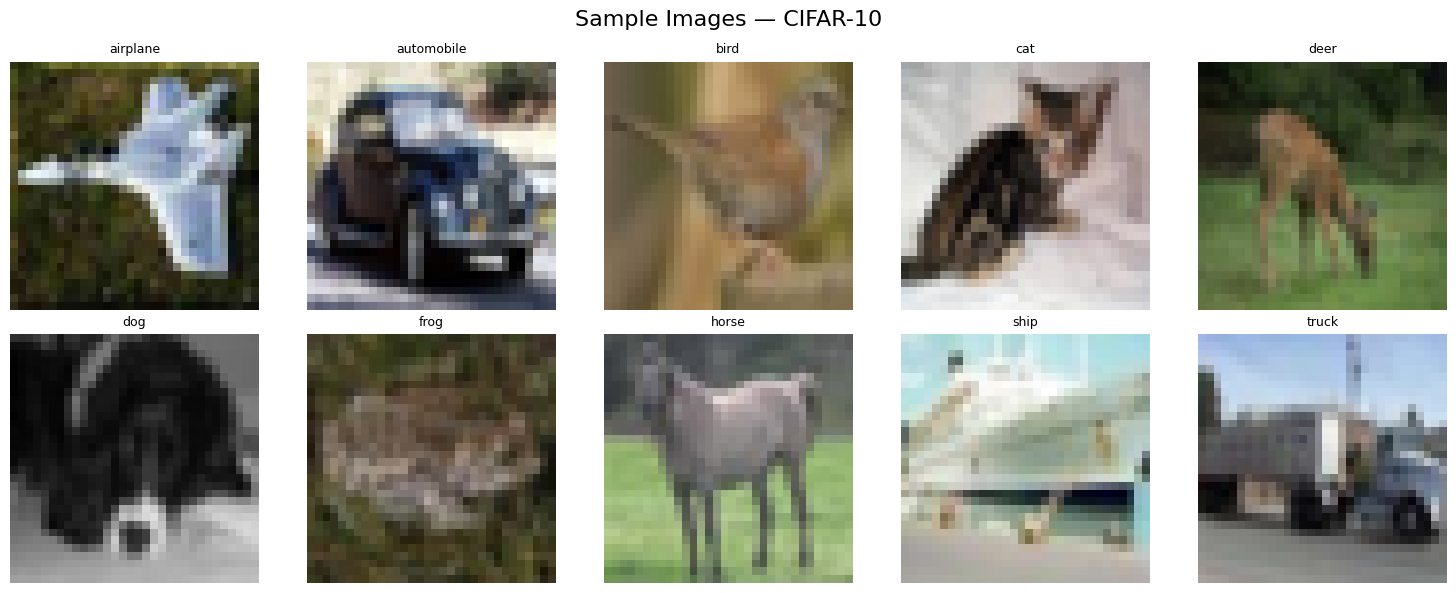

Saved to results/plots/CIFAR-10_samples.png


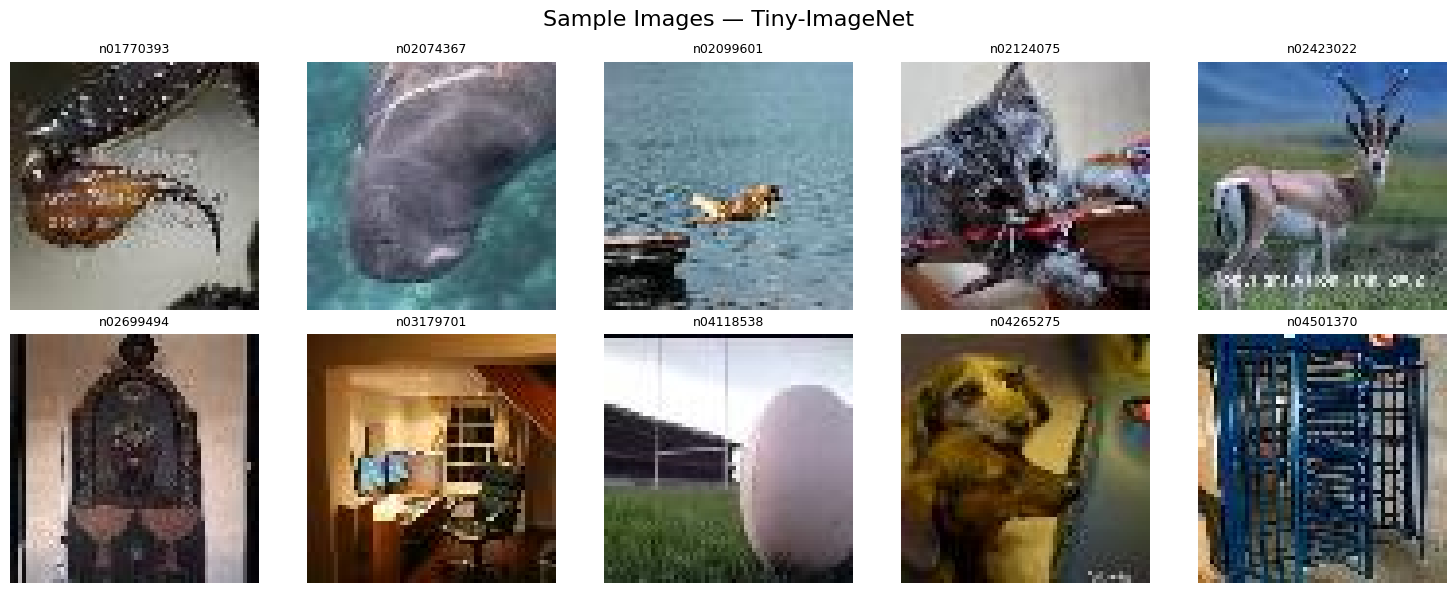

Saved to results/plots/Tiny-ImageNet_samples.png


In [13]:
# 2.What do the images look like?

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_sample_images(dataset_path, dataset_name, has_images_subfolder=False, num_images=10):
    classes = sorted(os.listdir(dataset_path))

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f"Sample Images — {dataset_name}", fontsize=16)

    for i, (ax, cls) in enumerate(zip(axes.flat, classes)):
        # Get path to images
        cls_path = os.path.join(dataset_path, cls)
        if has_images_subfolder:
            cls_path = os.path.join(cls_path, "images")

        # Pick first image from each class
        images = os.listdir(cls_path)
        img_path = os.path.join(cls_path, images[0])

        # Show image
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(cls, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"results/plots/{dataset_name}_samples.png")
    plt.show()
    print(f"Saved to results/plots/{dataset_name}_samples.png")

# Show one image per class for both datasets
show_sample_images(CIFAR10_TRAIN, "CIFAR-10", has_images_subfolder=False)
show_sample_images(TINY_TRAIN,    "Tiny-ImageNet", has_images_subfolder=True)

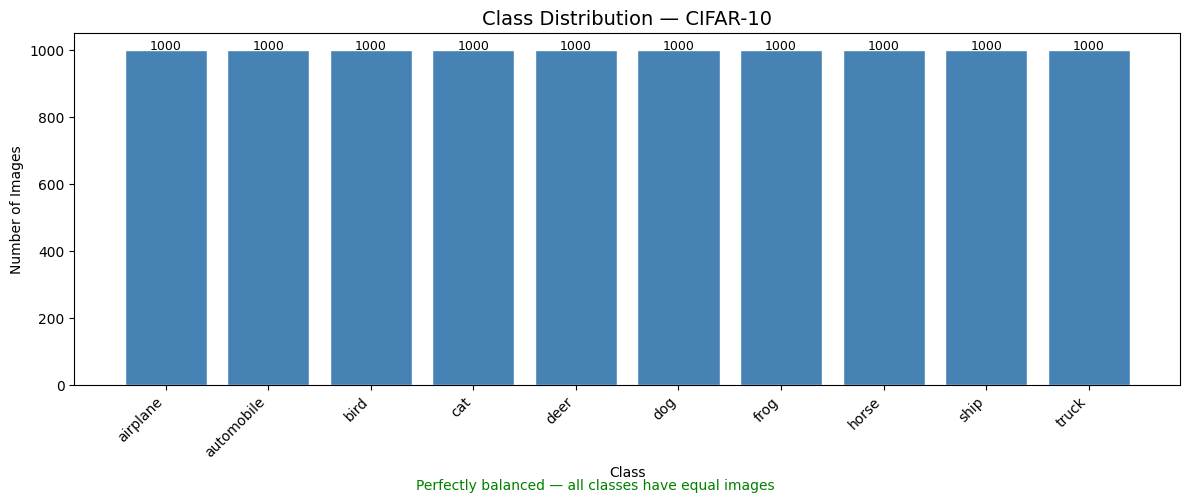

Min images: 1000  Max images: 1000
Balanced: True


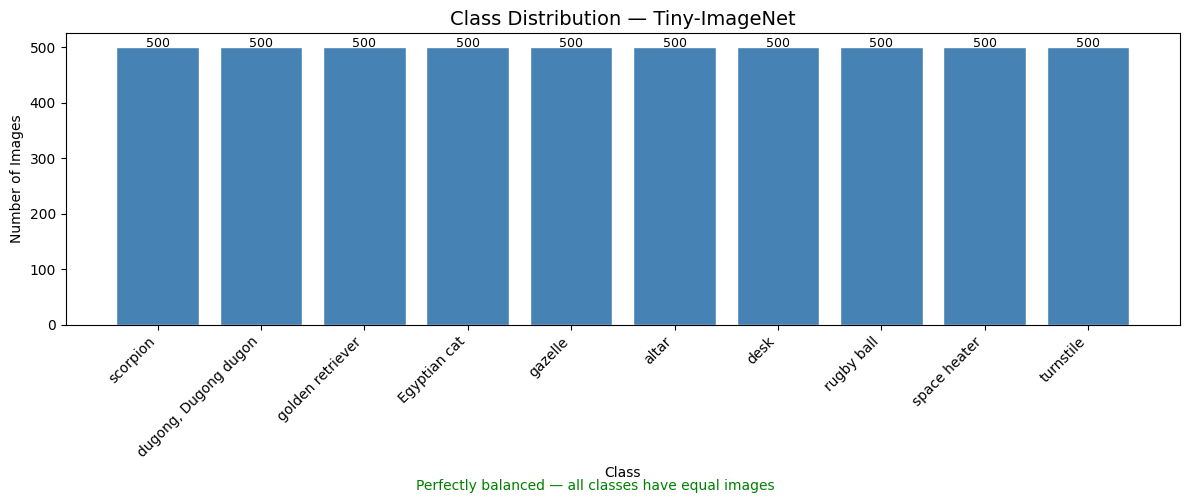

Min images: 500  Max images: 500
Balanced: True


In [14]:
# 3.Are the classes balanced?
def plot_class_distribution(dataset_path, dataset_name,
                             has_images_subfolder=False,
                             class_mapping=None):
    classes = sorted(os.listdir(dataset_path))
    counts  = []
    labels  = []

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        if has_images_subfolder:
            img_path = os.path.join(cls_path, "images")
        else:
            img_path = cls_path

        count = len(os.listdir(img_path))
        counts.append(count)

        # Use real name if mapping provided
        label = class_mapping.get(cls, cls) if class_mapping else cls
        labels.append(label)

    # Plot
    plt.figure(figsize=(12, 5))
    bars = plt.bar(labels, counts, color="steelblue", edgecolor="white")
    plt.title(f"Class Distribution — {dataset_name}", fontsize=14)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45, ha="right")

    # Add count on top of each bar
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(count), ha="center", fontsize=9)

    # Add balance check
    if len(set(counts)) == 1:
        plt.figtext(0.5, 0.01,
                    "Perfectly balanced — all classes have equal images",
                    ha="center", fontsize=10, color="green")
    else:
        plt.figtext(0.5, 0.01,
                    "Imbalanced — classes have different number of images",
                    ha="center", fontsize=10, color="red")

    plt.tight_layout()
    plt.savefig(f"results/plots/{dataset_name}_class_distribution.png")
    plt.show()
    print(f"Min images: {min(counts)}  Max images: {max(counts)}")
    print(f"Balanced: {len(set(counts)) == 1}")

# First build Tiny ImageNet class mapping
words_path = "/content/drive/MyDrive/CSE447/Datasets/tiny-imagenet-10/words.txt"
class_mapping = {}
with open(words_path, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            code, name = parts
            class_mapping[code] = name

# CIFAR-10 — no mapping needed, already has readable names
plot_class_distribution(CIFAR10_TRAIN, "CIFAR-10",
                        has_images_subfolder=False,
                        class_mapping=None)

# Tiny ImageNet — use mapping for readable names
plot_class_distribution(TINY_TRAIN, "Tiny-ImageNet",
                        has_images_subfolder=True,
                        class_mapping=class_mapping)

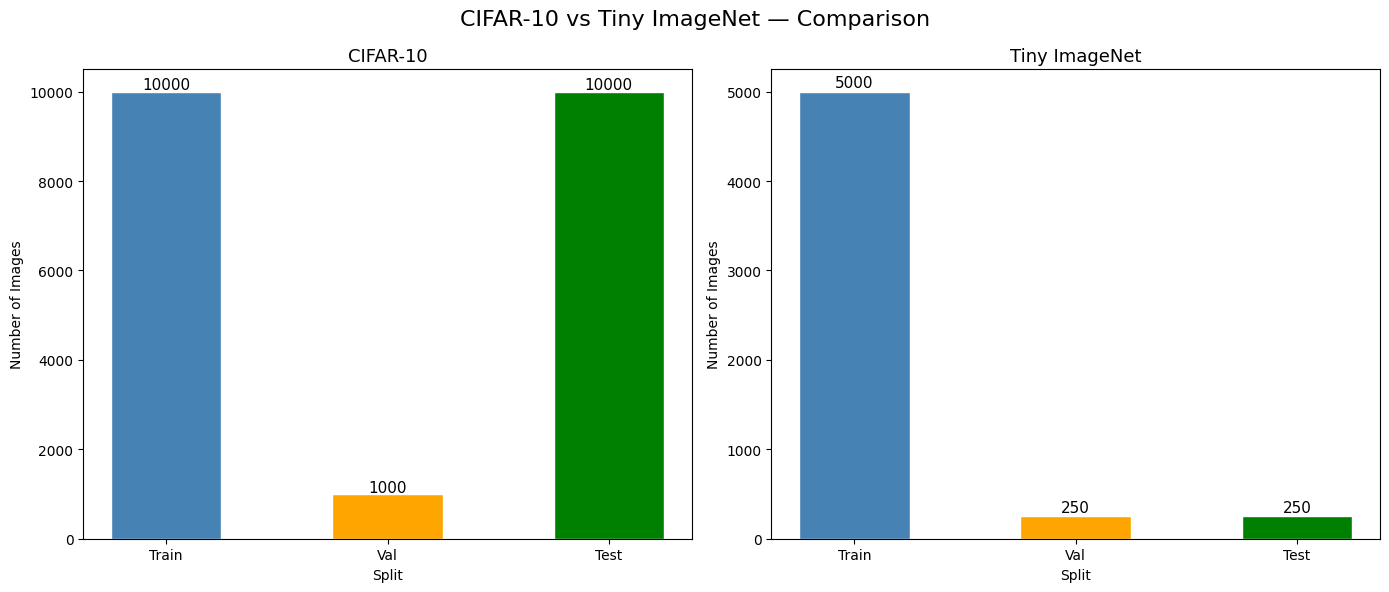

In [15]:
# 4.How are CIFAR-10 and Tiny ImageNet different?
def compare_datasets():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("CIFAR-10 vs Tiny ImageNet — Comparison", fontsize=16)

    datasets = [
        {
            "name":      "CIFAR-10",
            "train":     CIFAR10_TRAIN,
            "val":       CIFAR10_VAL,
            "test":      CIFAR10_TEST,
            "subfolder": False
        },
        {
            "name":      "Tiny ImageNet",
            "train":     TINY_TRAIN,
            "val":       TINY_VAL,
            "test":      TINY_TEST,
            "subfolder": True
        }
    ]

    for ax, ds in zip(axes, datasets):
        splits      = ["Train", "Val", "Test"]
        colors      = ["steelblue", "orange", "green"]
        totals      = []

        for path, has_sub in [(ds["train"], ds["subfolder"]),
                               (ds["val"],   ds["subfolder"]),
                               (ds["test"],  ds["subfolder"])]:
            classes = sorted(os.listdir(path))
            total   = 0
            for cls in classes:
                cls_path = os.path.join(path, cls)
                if os.path.isdir(cls_path):
                    img_path = os.path.join(cls_path, "images") if has_sub else cls_path
                    total += len(os.listdir(img_path))
            totals.append(total)

        bars = ax.bar(splits, totals, color=colors, edgecolor="white", width=0.5)
        ax.set_title(ds["name"], fontsize=13)
        ax.set_ylabel("Number of Images")
        ax.set_xlabel("Split")

        for bar, count in zip(bars, totals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 50,
                    str(count), ha="center", fontsize=11)

    plt.tight_layout()
    plt.savefig("results/plots/dataset_comparison.png")
    plt.show()

compare_datasets()

In [16]:
# Print Full summary
from PIL import Image

def full_comparison_summary():

    # Get image sizes
    cifar_cls   = os.listdir(CIFAR10_TRAIN)[0]
    cifar_img   = os.listdir(os.path.join(CIFAR10_TRAIN, cifar_cls))[0]
    cifar_size  = Image.open(os.path.join(CIFAR10_TRAIN, cifar_cls, cifar_img)).size

    tiny_cls    = os.listdir(TINY_TRAIN)[0]
    tiny_img    = os.listdir(os.path.join(TINY_TRAIN, tiny_cls, "images"))[0]
    tiny_size   = Image.open(os.path.join(TINY_TRAIN, tiny_cls, "images", tiny_img)).size

    print("=" * 55)
    print(f"{'':>5} {'CIFAR-10':>20} {'Tiny ImageNet':>20}")
    print("=" * 55)
    print(f"{'Classes':<20} {'10':>15} {'10':>20}")
    print(f"{'Image size':<20} {str(cifar_size):>15} {str(tiny_size):>20}")
    print(f"{'Train images':<20} {'10,000':>15} {'5,000':>20}")
    print(f"{'Val images':<20} {'1,000':>15} {'250':>20}")
    print(f"{'Test images':<20} {'10,000':>15} {'250':>20}")
    print(f"{'Total images':<20} {'21,000':>15} {'5,500':>20}")
    print(f"{'Balanced':<20} {'Yes':>15} {'Yes':>20}")
    print(f"{'Label format':<20} {'readable':>15} {'WordNet ID':>20}")
    print("=" * 55)

    print("\nKey differences:")
    print("  1. Image size  — CIFAR-10 is 32x32, Tiny ImageNet is 64x64")
    print("  2. Dataset size — CIFAR-10 has 4x more images overall")
    print("  3. Label names — CIFAR-10 uses plain names, Tiny ImageNet uses codes")
    print("  4. Test size   — CIFAR-10 test is 40x larger than Tiny ImageNet test")

full_comparison_summary()

                  CIFAR-10        Tiny ImageNet
Classes                           10                   10
Image size                  (32, 32)             (64, 64)
Train images                  10,000                5,000
Val images                     1,000                  250
Test images                   10,000                  250
Total images                  21,000                5,500
Balanced                         Yes                  Yes
Label format                readable           WordNet ID

Key differences:
  1. Image size  — CIFAR-10 is 32x32, Tiny ImageNet is 64x64
  2. Dataset size — CIFAR-10 has 4x more images overall
  3. Label names — CIFAR-10 uses plain names, Tiny ImageNet uses codes
  4. Test size   — CIFAR-10 test is 40x larger than Tiny ImageNet test


# Statistical analysis of Images using pixels




In [18]:
import numpy as np
from PIL import Image
import torch

def compute_dataset_stats(dataset_path, dataset_name, has_images_subfolder=False):
    """Computes mean and std of pixel values across all images."""

    print(f"\nComputing stats for {dataset_name}...")
    print("This may take a minute...")

    all_pixels = []
    classes = sorted(os.listdir(dataset_path))

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        img_path = os.path.join(cls_path, "images") if has_images_subfolder else cls_path

        for img_file in os.listdir(img_path):
            full_path = os.path.join(img_path, img_file)
            try:
                img = Image.open(full_path).convert("RGB")
                img_array = np.array(img) / 255.0  # normalize to 0-1
                all_pixels.append(img_array)
            except:
                continue

    all_pixels = np.array(all_pixels)  # shape: (N, H, W, 3)

    mean = all_pixels.mean(axis=(0,1,2))  # mean per channel
    std  = all_pixels.std(axis=(0,1,2))   # std per channel

    print(f"\n{'='*45}")
    print(f"  Stats — {dataset_name}")
    print(f"{'='*45}")
    print(f"  Mean (R, G, B) : {mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}")
    print(f"  Std  (R, G, B) : {std[0]:.4f},  {std[1]:.4f},  {std[2]:.4f}")
    print(f"  Min pixel value: {all_pixels.min():.4f}")
    print(f"  Max pixel value: {all_pixels.max():.4f}")
    print(f"  Image shape    : {all_pixels.shape[1]}x{all_pixels.shape[2]}")
    print(f"  Total images   : {all_pixels.shape[0]}")
    print(f"{'='*45}")

    return mean, std

# Run on training sets only — val and test use same stats
cifar_mean, cifar_std = compute_dataset_stats(
    CIFAR10_TRAIN, "CIFAR-10", has_images_subfolder=False)

tiny_mean, tiny_std = compute_dataset_stats(
    TINY_TRAIN, "Tiny ImageNet", has_images_subfolder=True)


Computing stats for CIFAR-10...
This may take a minute...

  Stats — CIFAR-10
  Mean (R, G, B) : 0.4925, 0.4828, 0.4478
  Std  (R, G, B) : 0.2470,  0.2438,  0.2618
  Min pixel value: 0.0000
  Max pixel value: 1.0000
  Image shape    : 32x32
  Total images   : 10000

Computing stats for Tiny ImageNet...
This may take a minute...

  Stats — Tiny ImageNet
  Mean (R, G, B) : 0.4674, 0.4490, 0.3984
  Std  (R, G, B) : 0.2712,  0.2587,  0.2671
  Min pixel value: 0.0000
  Max pixel value: 1.0000
  Image shape    : 64x64
  Total images   : 5000


# Visualizing Pixel HeatMap 1 image for each class

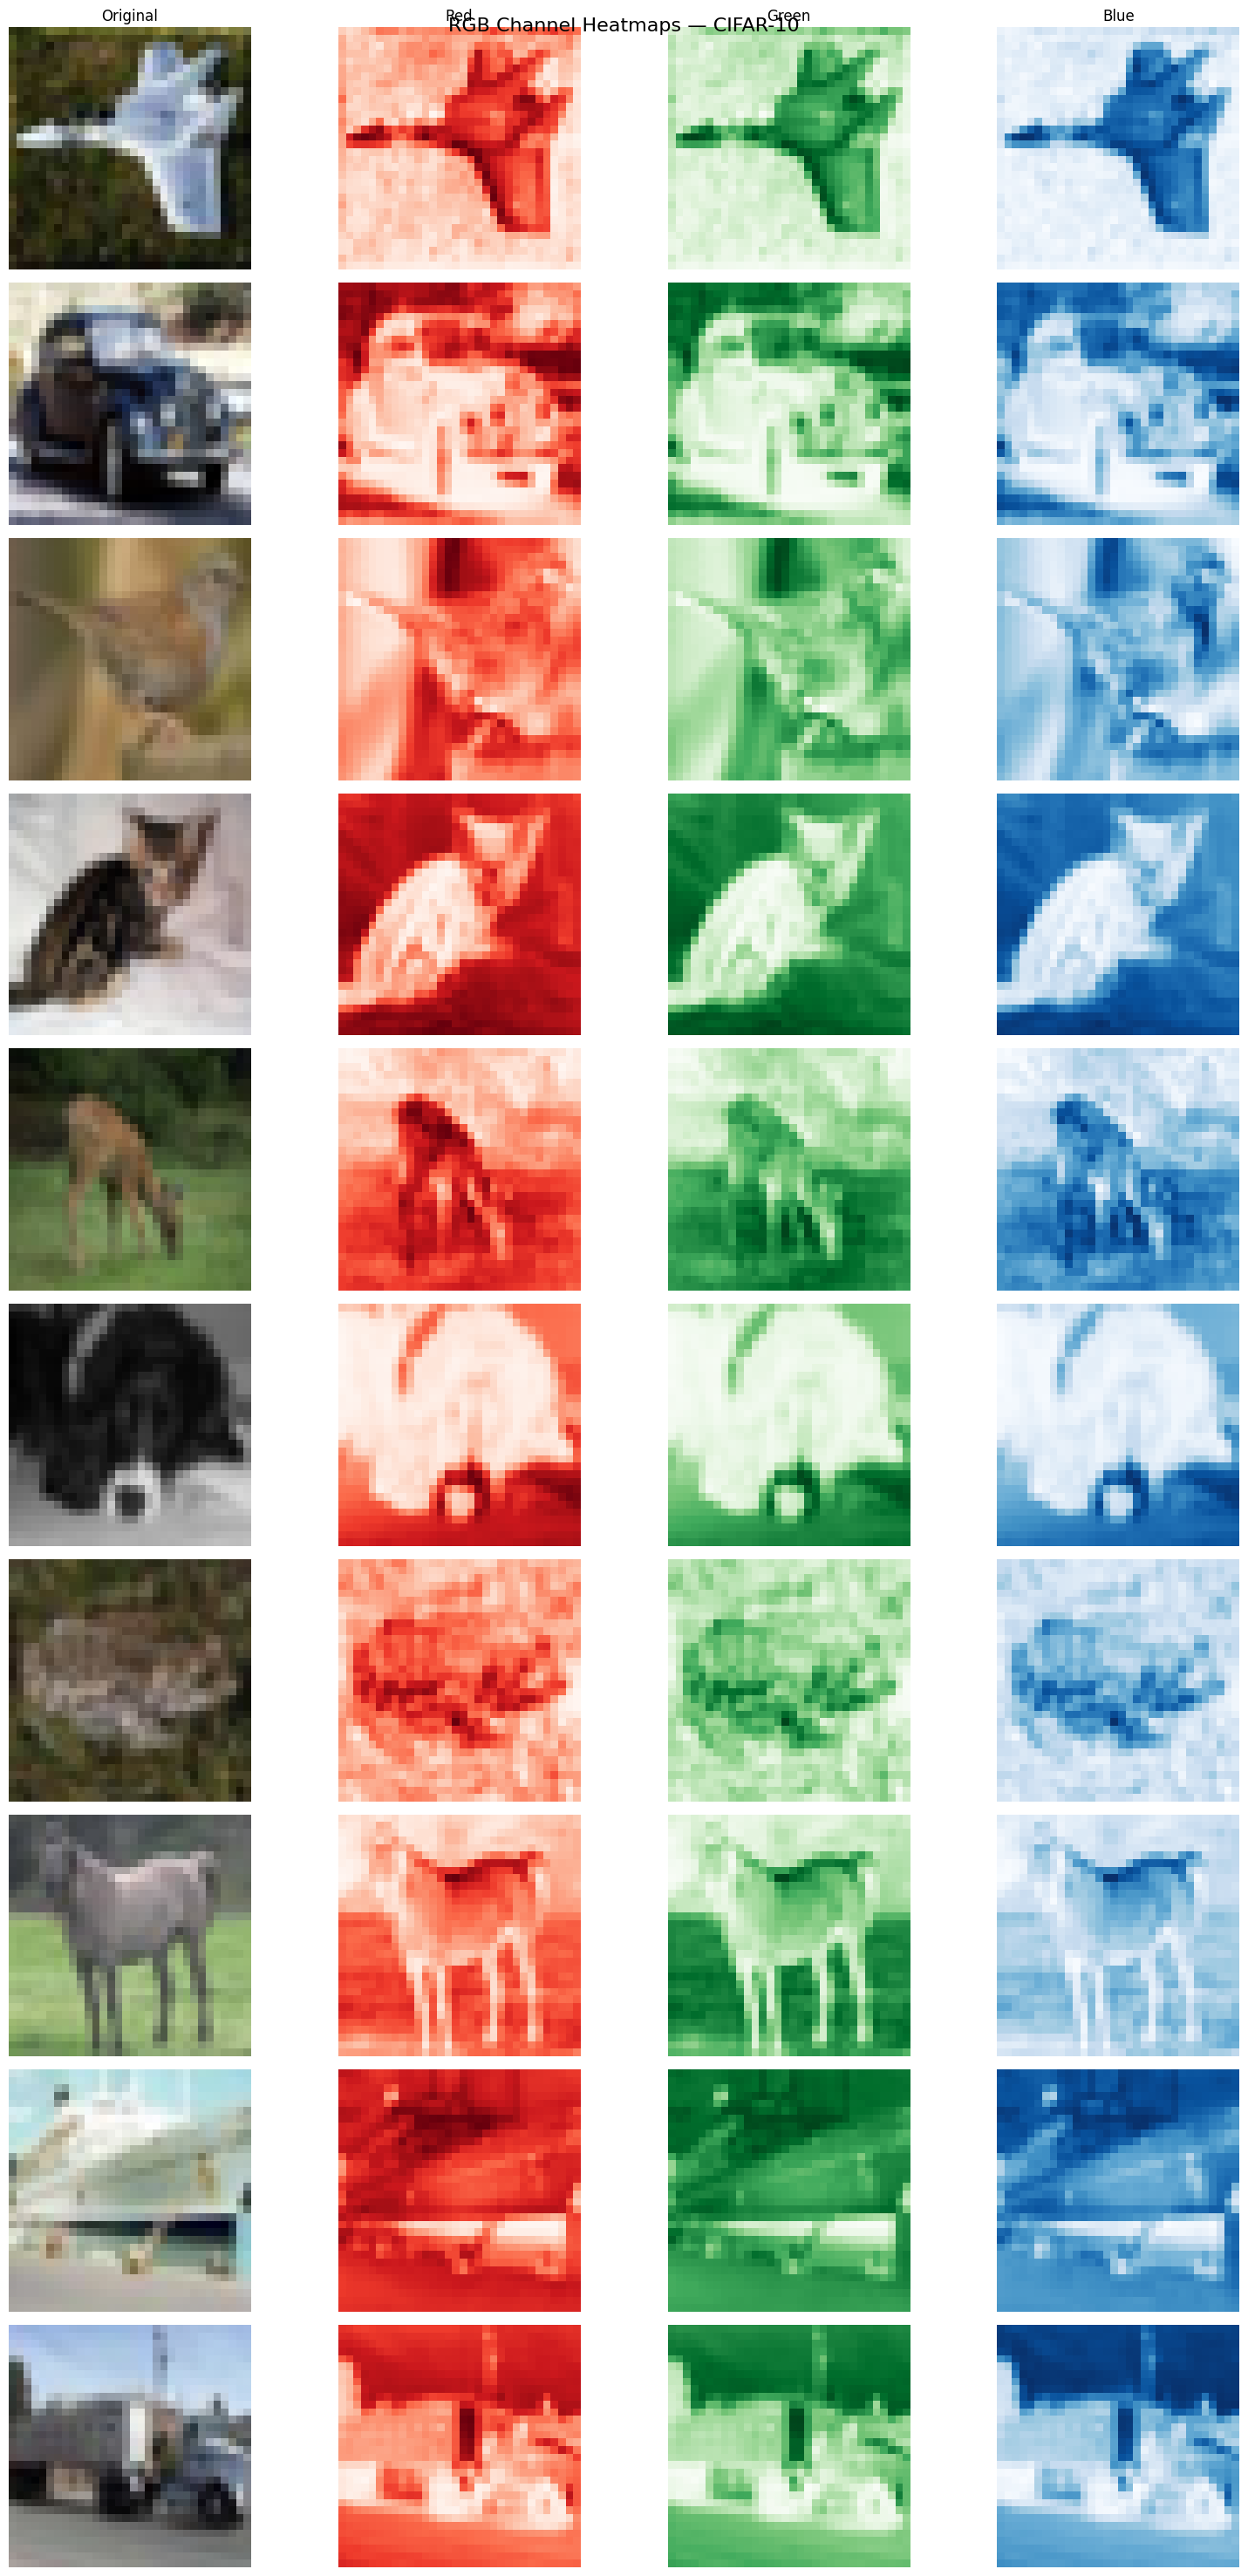

Saved to results/plots/CIFAR-10_class_heatmaps.png


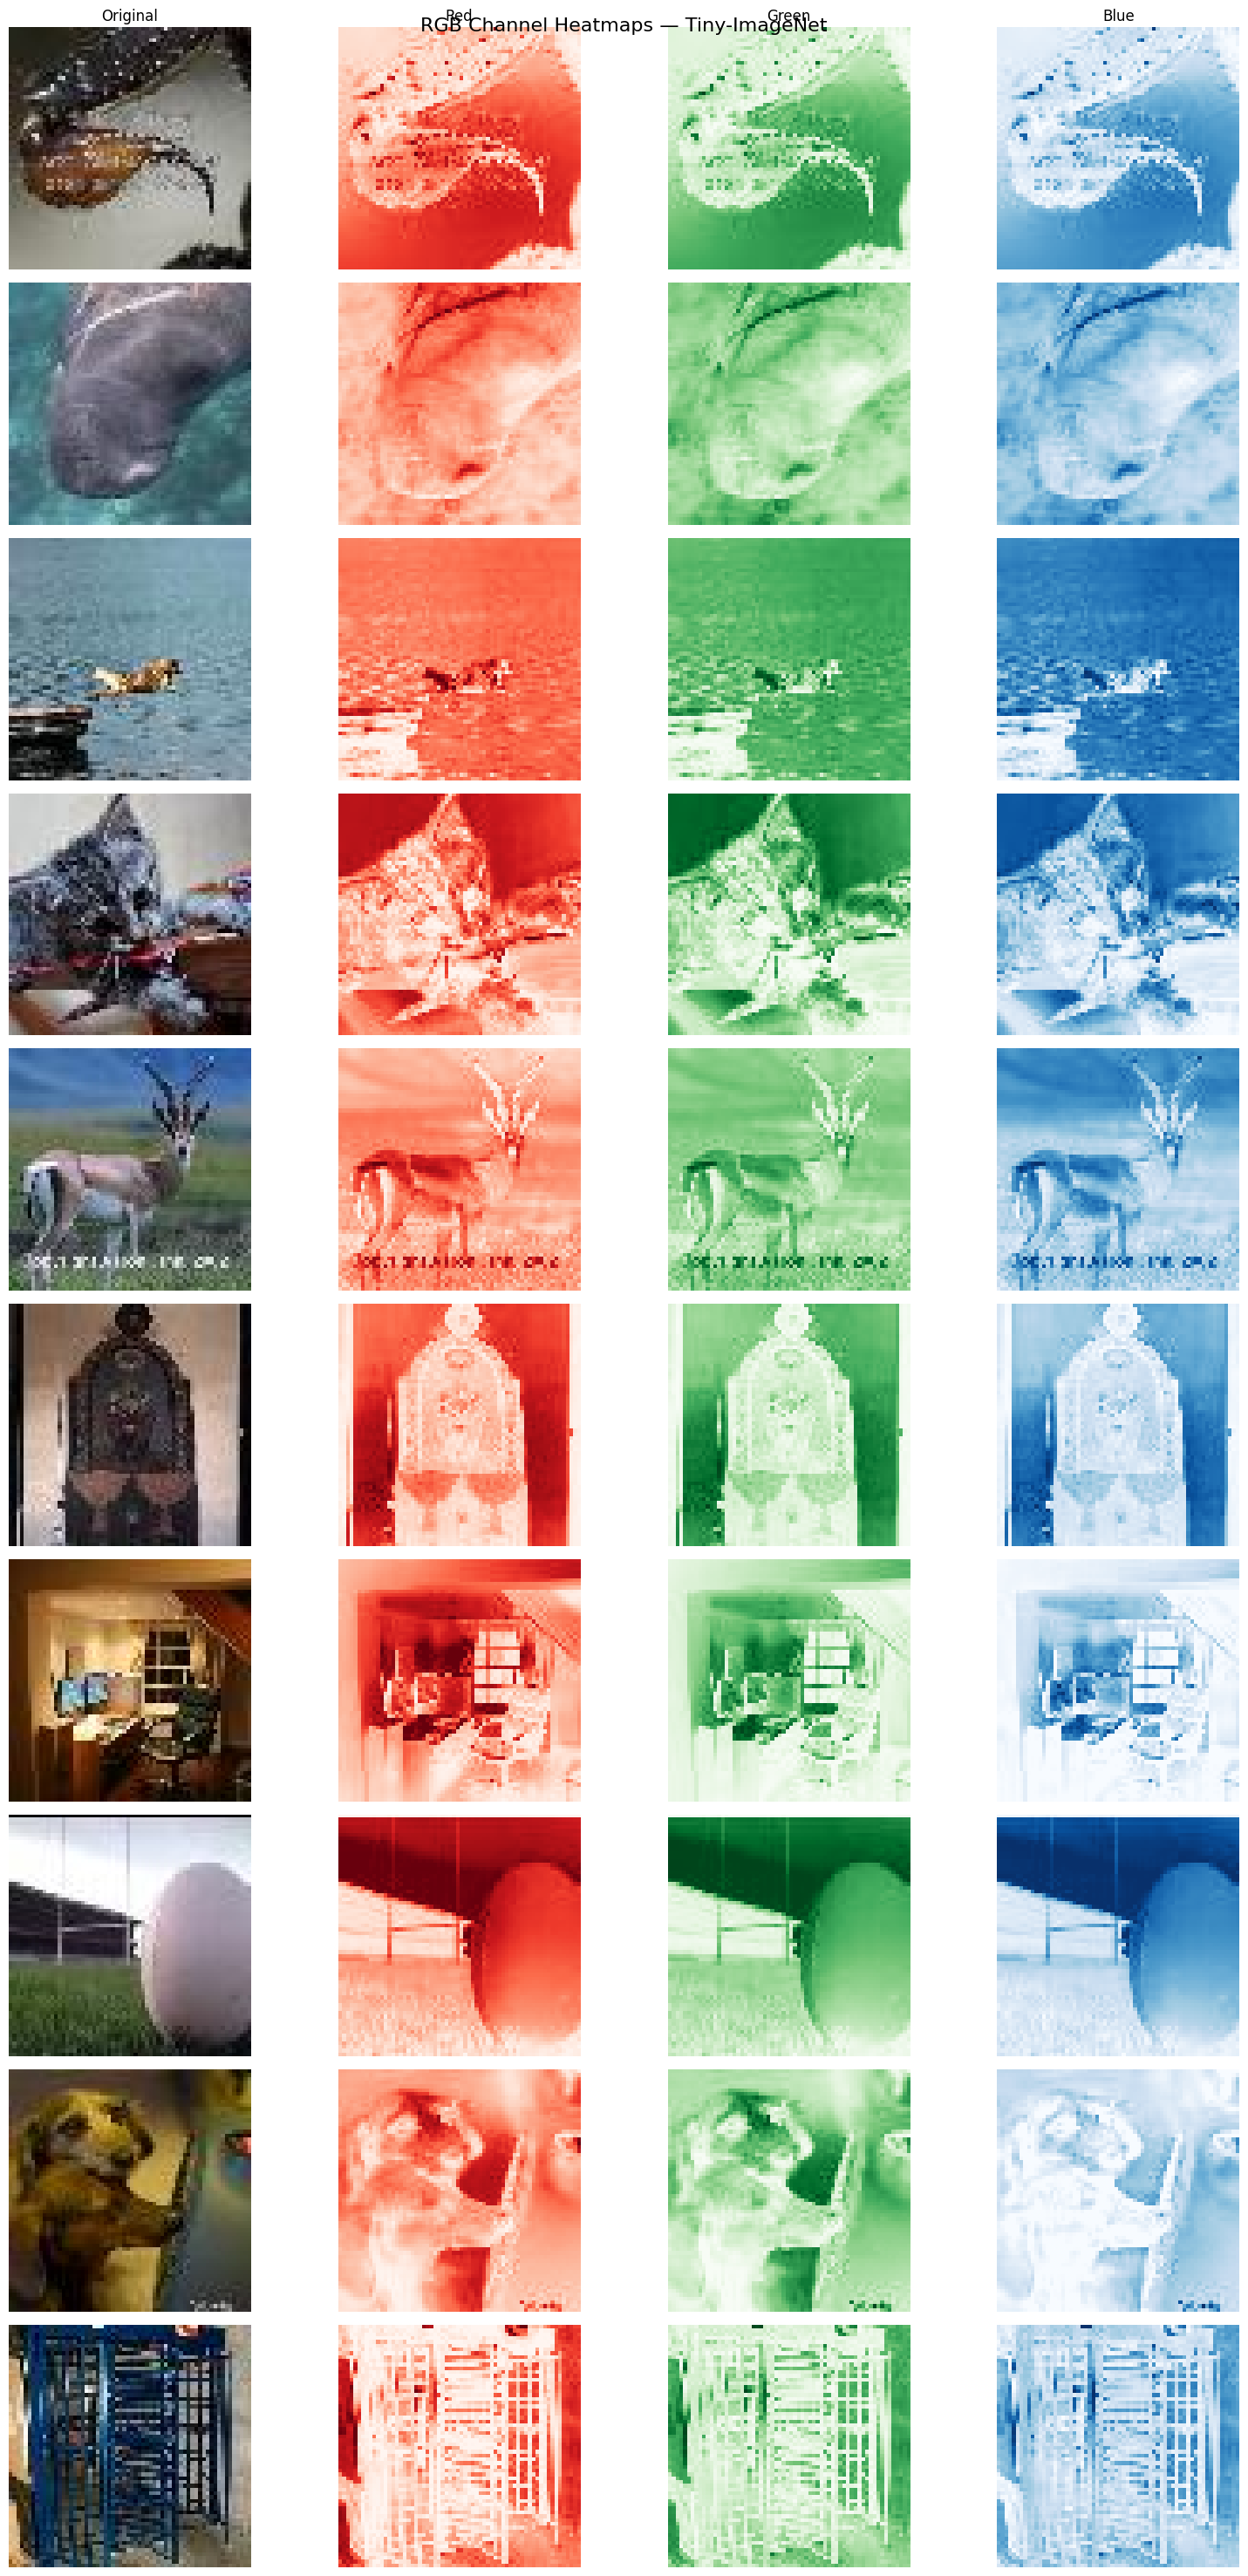

Saved to results/plots/Tiny-ImageNet_class_heatmaps.png


In [19]:
# Cell — Show heatmap for one image per class

def show_class_heatmaps(dataset_path, dataset_name,
                         has_images_subfolder=False,
                         class_mapping=None):
    """
    Shows RGB channel heatmap for one image from each class
    """
    classes = sorted(os.listdir(dataset_path))

    fig, axes = plt.subplots(len(classes), 4,
                              figsize=(16, len(classes) * 3))
    fig.suptitle(f"RGB Channel Heatmaps — {dataset_name}",
                 fontsize=16)

    for row, cls in enumerate(classes):
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        img_path = os.path.join(cls_path, "images") if has_images_subfolder else cls_path
        img_file = os.listdir(img_path)[0]
        img_array = np.array(Image.open(
                    os.path.join(img_path, img_file)).convert("RGB"))

        # Get readable class name
        label = class_mapping.get(cls, cls) if class_mapping else cls

        # Original image
        axes[row, 0].imshow(img_array)
        axes[row, 0].set_ylabel(label, fontsize=10)
        axes[row, 0].set_title("Original" if row == 0 else "")
        axes[row, 0].axis("off")

        # RGB channels
        channels = ["Red", "Green", "Blue"]
        cmaps    = ["Reds", "Greens", "Blues"]
        for col, (name, cmap) in enumerate(zip(channels, cmaps)):
            axes[row, col+1].imshow(img_array[:,:,col], cmap=cmap)
            axes[row, col+1].set_title(name if row == 0 else "")
            axes[row, col+1].axis("off")

    plt.tight_layout()
    plt.savefig(f"results/plots/{dataset_name}_class_heatmaps.png")
    plt.show()
    print(f"Saved to results/plots/{dataset_name}_class_heatmaps.png")

# Run for both datasets
show_class_heatmaps(CIFAR10_TRAIN, "CIFAR-10",
                    has_images_subfolder=False,
                    class_mapping=None)

show_class_heatmaps(TINY_TRAIN, "Tiny-ImageNet",
                    has_images_subfolder=True,
                    class_mapping=class_mapping)

# Average HeatMap across all images in both datasets

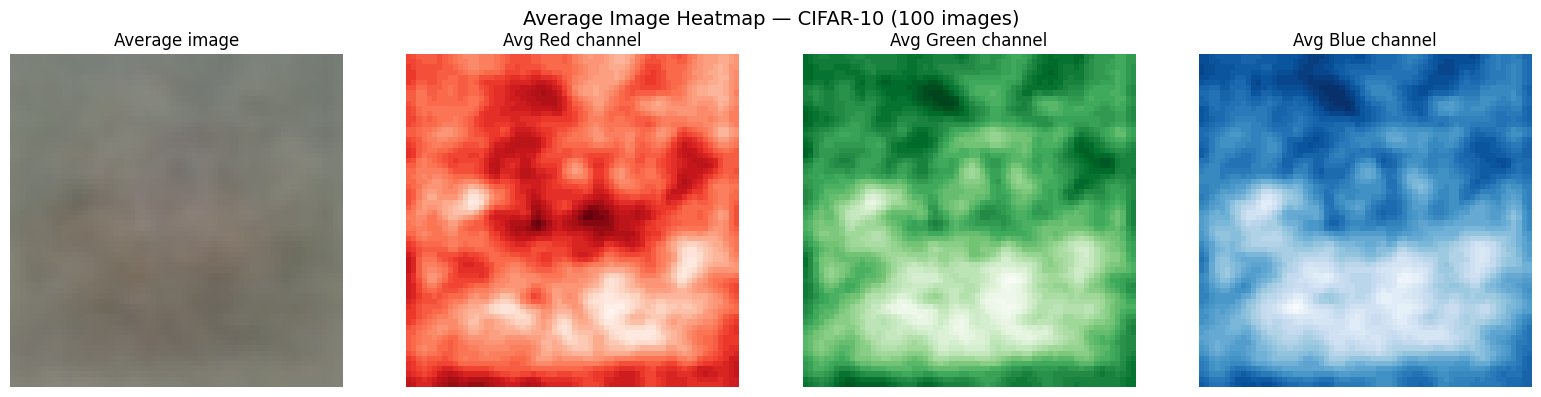


Average pixel values across 100 images:
  Red   channel mean: 122.9
  Green channel mean: 121.0
  Blue  channel mean: 110.8


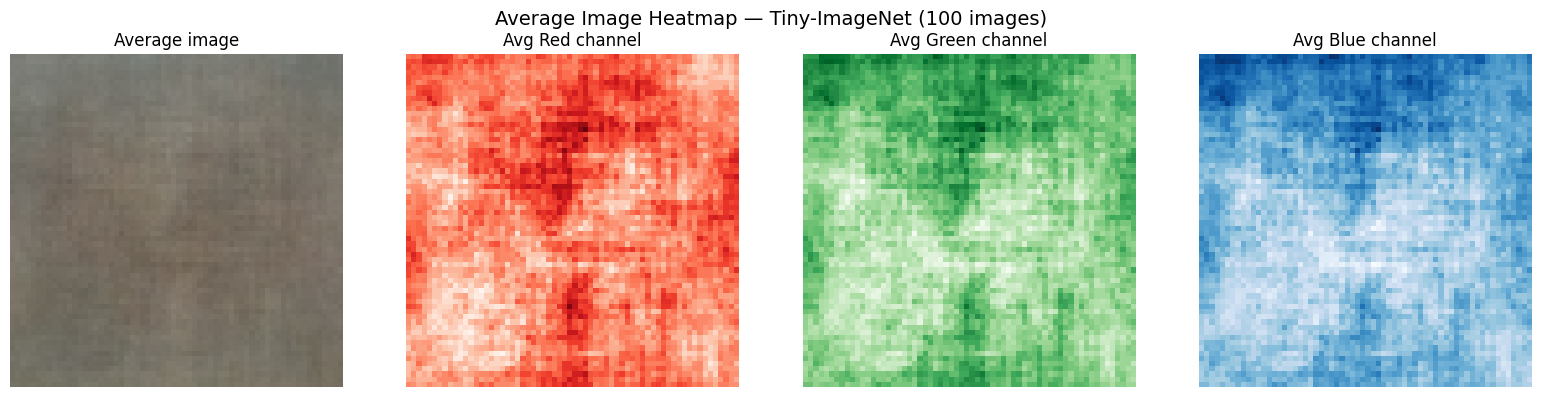


Average pixel values across 100 images:
  Red   channel mean: 118.8
  Green channel mean: 112.7
  Blue  channel mean: 101.6


In [20]:
# Cell — Average brightness heatmap across dataset

def show_average_heatmap(dataset_path, dataset_name,
                          has_images_subfolder=False,
                          sample_size=100):
    """
    Shows average pixel brightness across sample_size images
    Reveals if images tend to be brighter in certain regions
    """
    classes    = sorted(os.listdir(dataset_path))
    all_images = []

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        img_path = os.path.join(cls_path, "images") if has_images_subfolder else cls_path
        images   = os.listdir(img_path)

        # Sample from each class
        import random
        sampled = random.sample(images, min(sample_size//len(classes), len(images)))

        for img_file in sampled:
            full_path = os.path.join(img_path, img_file)
            try:
                img = Image.open(full_path).convert("RGB")
                # Resize all to same size for averaging
                img = img.resize((64, 64))
                all_images.append(np.array(img))
            except:
                continue

    # Average across all images
    avg_image = np.mean(all_images, axis=0).astype(np.uint8)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"Average Image Heatmap — {dataset_name} ({len(all_images)} images)",
                 fontsize=14)

    axes[0].imshow(avg_image)
    axes[0].set_title("Average image")
    axes[0].axis("off")

    channels = ["Red", "Green", "Blue"]
    cmaps    = ["Reds", "Greens", "Blues"]
    for i, (name, cmap) in enumerate(zip(channels, cmaps)):
        axes[i+1].imshow(avg_image[:,:,i], cmap=cmap)
        axes[i+1].set_title(f"Avg {name} channel")
        axes[i+1].axis("off")

    plt.tight_layout()
    plt.savefig(f"results/plots/{dataset_name}_avg_heatmap.png")
    plt.show()

    print(f"\nAverage pixel values across {len(all_images)} images:")
    print(f"  Red   channel mean: {avg_image[:,:,0].mean():.1f}")
    print(f"  Green channel mean: {avg_image[:,:,1].mean():.1f}")
    print(f"  Blue  channel mean: {avg_image[:,:,2].mean():.1f}")

# Run for both datasets
show_average_heatmap(CIFAR10_TRAIN, "CIFAR-10",
                     has_images_subfolder=False,
                     sample_size=100)

show_average_heatmap(TINY_TRAIN, "Tiny-ImageNet",
                     has_images_subfolder=True,
                     sample_size=100)

# Pixel Histogram for 200 images in both the datasets

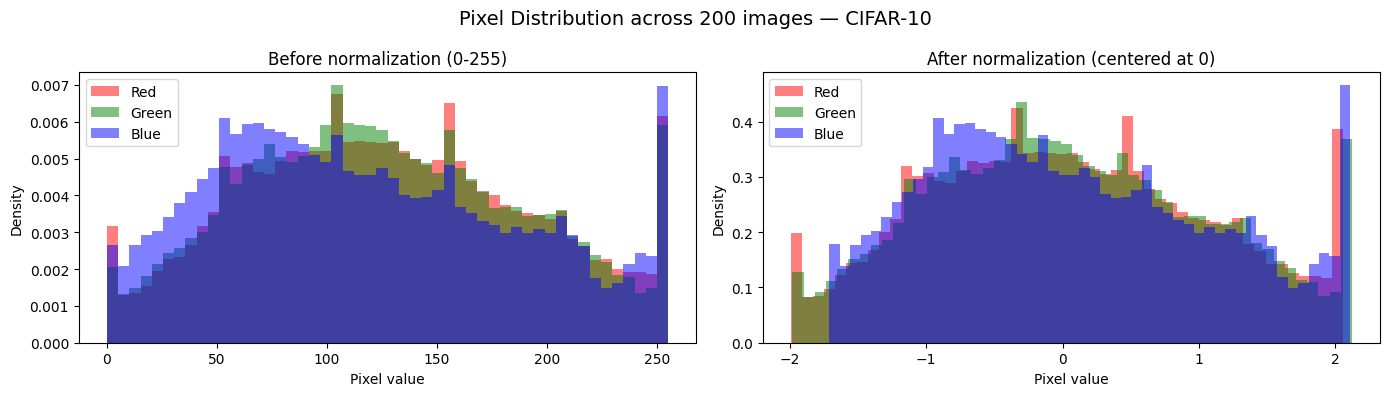


Sampled 200 images from CIFAR-10
Total pixels analyzed: 204,800


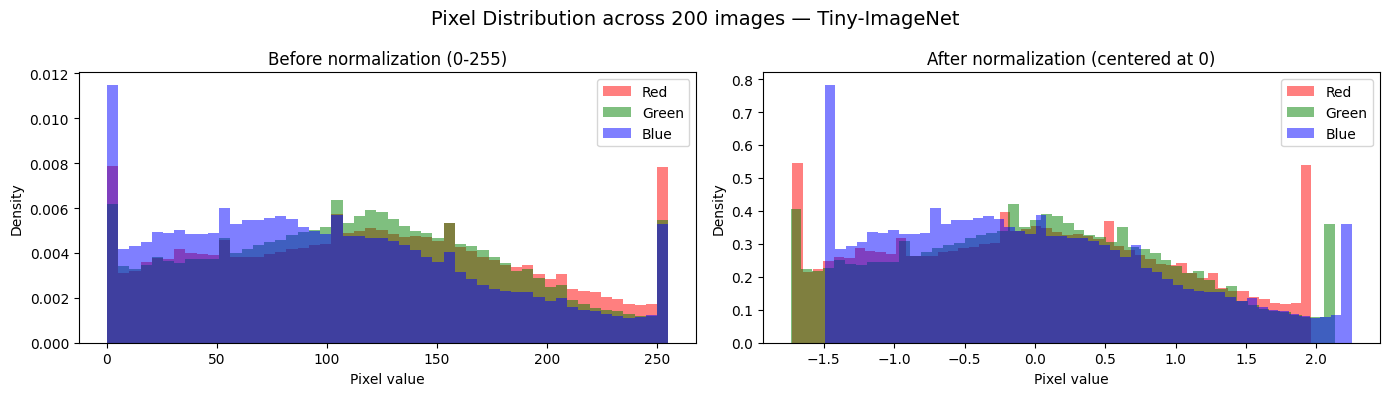


Sampled 200 images from Tiny-ImageNet
Total pixels analyzed: 819,200


In [21]:
# Cell — Average pixel histogram across ALL images

def show_average_pixel_histogram(dataset_path, dataset_name,
                                  has_images_subfolder=False,
                                  sample_size=200):
    """
    Shows pixel distribution across a sample of images
    sample_size=200 means we look at 200 random images
    not all 10,000 — that would take too long
    """
    import random

    all_r, all_g, all_b = [], [], []
    classes = sorted(os.listdir(dataset_path))

    # Collect pixels from sample_size images
    count = 0
    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        img_path = os.path.join(cls_path, "images") if has_images_subfolder else cls_path
        images   = os.listdir(img_path)

        # Take random sample from each class
        sampled = random.sample(images, min(sample_size//len(classes), len(images)))

        for img_file in sampled:
            full_path = os.path.join(img_path, img_file)
            try:
                img       = Image.open(full_path).convert("RGB")
                img_array = np.array(img)
                all_r.extend(img_array[:,:,0].flatten().tolist())
                all_g.extend(img_array[:,:,1].flatten().tolist())
                all_b.extend(img_array[:,:,2].flatten().tolist())
                count += 1
            except:
                continue

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Pixel Distribution across {count} images — {dataset_name}",
                 fontsize=14)

    # Before normalization
    axes[0].hist(all_r, bins=50, alpha=0.5, color="red",   label="Red",   density=True)
    axes[0].hist(all_g, bins=50, alpha=0.5, color="green", label="Green", density=True)
    axes[0].hist(all_b, bins=50, alpha=0.5, color="blue",  label="Blue",  density=True)
    axes[0].set_title(f"Before normalization (0-255)")
    axes[0].set_xlabel("Pixel value")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # After normalization
    mean     = np.array(CIFAR_MEAN if "CIFAR" in dataset_name else TINY_MEAN)
    std      = np.array(CIFAR_STD  if "CIFAR" in dataset_name else TINY_STD)
    all_r_n  = ((np.array(all_r) / 255.0) - mean[0]) / std[0]
    all_g_n  = ((np.array(all_g) / 255.0) - mean[1]) / std[1]
    all_b_n  = ((np.array(all_b) / 255.0) - mean[2]) / std[2]

    axes[1].hist(all_r_n, bins=50, alpha=0.5, color="red",   label="Red",   density=True)
    axes[1].hist(all_g_n, bins=50, alpha=0.5, color="green", label="Green", density=True)
    axes[1].hist(all_b_n, bins=50, alpha=0.5, color="blue",  label="Blue",  density=True)
    axes[1].set_title(f"After normalization (centered at 0)")
    axes[1].set_xlabel("Pixel value")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"results/plots/{dataset_name}_avg_histogram.png")
    plt.show()

    print(f"\nSampled {count} images from {dataset_name}")
    print(f"Total pixels analyzed: {len(all_r):,}")

# Run for both datasets
show_average_pixel_histogram(CIFAR10_TRAIN, "CIFAR-10",
                              has_images_subfolder=False,
                              sample_size=200)

show_average_pixel_histogram(TINY_TRAIN, "Tiny-ImageNet",
                              has_images_subfolder=True,
                              sample_size=200)

# Image Corruption Check

In [22]:
def check_image_corruption(dataset_path, dataset_name,
                            has_images_subfolder=False):
    """
    Goes through every image and checks if it can be opened.
    Reports any corrupted or problematic images.
    """
    classes       = sorted(os.listdir(dataset_path))
    total         = 0
    corrupted     = []
    wrong_mode    = []
    wrong_size    = []

    print(f"\nChecking {dataset_name}...")
    print("-" * 40)

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        img_path = os.path.join(cls_path, "images") if has_images_subfolder else cls_path

        for img_file in os.listdir(img_path):
            full_path = os.path.join(img_path, img_file)
            total += 1

            try:
                img = Image.open(full_path)
                img.verify()  # checks if file is corrupted

                # Reopen after verify — verify closes the file
                img = Image.open(full_path).convert("RGB")

                # Check image mode
                if img.mode != "RGB":
                    wrong_mode.append({
                        "file":  full_path,
                        "mode":  img.mode
                    })

                # Check image size is consistent
                expected_size = (32, 32) if "CIFAR" in dataset_name else (64, 64)
                if img.size != expected_size:
                    wrong_size.append({
                        "file": full_path,
                        "size": img.size
                    })

            except Exception as e:
                corrupted.append({
                    "file":  full_path,
                    "error": str(e)
                })

    # Print results
    print(f"\n  Total images checked : {total}")
    print(f"  Corrupted images     : {len(corrupted)}")
    print(f"  Wrong mode           : {len(wrong_mode)}")
    print(f"  Unexpected size      : {len(wrong_size)}")

    if len(corrupted) == 0 and len(wrong_mode) == 0 and len(wrong_size) == 0:
        print(f"\n  All images are clean!")
    else:
        if corrupted:
            print(f"\n  Corrupted files:")
            for item in corrupted[:5]:  # show first 5 only
                print(f"    {item['file']}")
                print(f"    Error: {item['error']}")

        if wrong_mode:
            print(f"\n  Wrong mode files (not RGB):")
            for item in wrong_mode[:5]:
                print(f"    {item['file']} — mode: {item['mode']}")

        if wrong_size:
            print(f"\n  Unexpected size files:")
            for item in wrong_size[:5]:
                print(f"    {item['file']} — size: {item['size']}")

    print("-" * 40)
    return corrupted, wrong_mode, wrong_size

# Check all splits for both datasets
print("=" * 50)
print("CIFAR-10 corruption check")
print("=" * 50)
cifar_train_bad, _, _ = check_image_corruption(
    CIFAR10_TRAIN, "CIFAR-10", has_images_subfolder=False)
cifar_val_bad,   _, _ = check_image_corruption(
    CIFAR10_VAL,   "CIFAR-10", has_images_subfolder=False)
cifar_test_bad,  _, _ = check_image_corruption(
    CIFAR10_TEST,  "CIFAR-10", has_images_subfolder=False)

print("\n" + "=" * 50)
print("Tiny ImageNet corruption check")
print("=" * 50)
tiny_train_bad, _, _ = check_image_corruption(
    TINY_TRAIN, "Tiny-ImageNet", has_images_subfolder=True)
tiny_val_bad,   _, _ = check_image_corruption(
    TINY_VAL,   "Tiny-ImageNet", has_images_subfolder=True)
tiny_test_bad,  _, _ = check_image_corruption(
    TINY_TEST,  "Tiny-ImageNet", has_images_subfolder=True)

# Final summary
print("\n" + "=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
total_bad = (len(cifar_train_bad) + len(cifar_val_bad) +
             len(cifar_test_bad)  + len(tiny_train_bad) +
             len(tiny_val_bad)    + len(tiny_test_bad))

if total_bad == 0:
    print("Both datasets are clean — no corrupted images found!")
    print("Safe to proceed to model training.")
else:
    print(f"Found {total_bad} problematic images across both datasets")
    print("These should be removed before training!")

CIFAR-10 corruption check

Checking CIFAR-10...
----------------------------------------

  Total images checked : 10000
  Corrupted images     : 0
  Wrong mode           : 0
  Unexpected size      : 0

  All images are clean!
----------------------------------------

Checking CIFAR-10...
----------------------------------------

  Total images checked : 1000
  Corrupted images     : 0
  Wrong mode           : 0
  Unexpected size      : 0

  All images are clean!
----------------------------------------

Checking CIFAR-10...
----------------------------------------

  Total images checked : 10000
  Corrupted images     : 0
  Wrong mode           : 0
  Unexpected size      : 0

  All images are clean!
----------------------------------------

Tiny ImageNet corruption check

Checking Tiny-ImageNet...
----------------------------------------

  Total images checked : 5000
  Corrupted images     : 0
  Wrong mode           : 0
  Unexpected size      : 0

  All images are clean!
------------

# Push to github

In [ ]:
# Set Git identity
!git config --global user.email "sik324@lehigh.edu"
!git config --global user.name "Sirisha"

In [ ]:
!git add utils/eda.py
!git commit -m "add complete eda.py with all EDA functions"
!git push https://OUR_TOKEN_HERE@github.com/sik324/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision.git

#Dataloader for train dataset. In this prostep we will
1. Find images in all folders.
2. Random Horizontal Flip
3. Random Crop
4. TOTensor
5. Normalize
6. DataLoader(groups into batches of 64
7. CNN ready batch

In [23]:
%%writefile utils/dataset_train.py

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# ── CIFAR-10 training loader ─────────────────────────────────────────
def get_cifar10_train_loader(data_path, batch_size=64):
    """
    Loads CIFAR-10 training images.
    Applies augmentation + normalization.

    Args:
        data_path  : path to cifar10/train folder
        batch_size : images per batch (default 64)
    Returns:
        train_loader : DataLoader ready for CNN
    """
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4925, 0.4828, 0.4478],
            std= [0.2470, 0.2438, 0.2618]
        )
    ])

    dataset = ImageFolder(data_path, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = True,
        num_workers = 2,
        pin_memory  = True
    )

    print(f"CIFAR-10 train loader ready!")
    print(f"  Images    : {len(dataset)}")
    print(f"  Classes   : {dataset.classes}")
    print(f"  Batches   : {len(loader)}")
    print(f"  Batch size: {batch_size}")

    return loader


# ── Tiny ImageNet training loader ────────────────────────────────────
def get_tinyimagenet_train_loader(data_path, batch_size=64):
    """
    Loads Tiny ImageNet training images.
    Applies augmentation + normalization.
    Note: Tiny ImageNet has extra images/ subfolder inside each class.

    Args:
        data_path  : path to tiny-imagenet-10/train folder
        batch_size : images per batch (default 64)
    Returns:
        train_loader : DataLoader ready for CNN
    """
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(64, padding=8),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4674, 0.4490, 0.3984],
            std= [0.2712, 0.2587, 0.2671]
        )
    ])

    dataset = ImageFolder(data_path, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = True,
        num_workers = 2,
        pin_memory  = True
    )

    print(f"Tiny ImageNet train loader ready!")
    print(f"  Images    : {len(dataset)}")
    print(f"  Classes   : {dataset.classes}")
    print(f"  Batches   : {len(loader)}")
    print(f"  Batch size: {batch_size}")

    return loader

Overwriting utils/dataset_train.py


# Test dataset_train.py

In [24]:
# Import our new loader
from utils.dataset_train import get_cifar10_train_loader, get_tinyimagenet_train_loader

# Test CIFAR-10 loader
print("Testing CIFAR-10 train loader...")
cifar_train_loader = get_cifar10_train_loader(CIFAR10_TRAIN, batch_size=64)

# Grab one batch and check shape
images, labels = next(iter(cifar_train_loader))
print(f"\nOne batch:")
print(f"  Images shape : {images.shape}")   # should be [64, 3, 32, 32]
print(f"  Labels shape : {labels.shape}")   # should be [64]
print(f"  Pixel range  : {images.min():.3f} to {images.max():.3f}")  # should be around -2 to +2

Testing CIFAR-10 train loader...
CIFAR-10 train loader ready!
  Images    : 10000
  Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Batches   : 157
  Batch size: 64


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



One batch:
  Images shape : torch.Size([64, 3, 32, 32])
  Labels shape : torch.Size([64])
  Pixel range  : -1.994 to 2.121


# Test TinyImageNet Loader

In [25]:
print("Testing Tiny ImageNet train loader...")
tiny_train_loader = get_tinyimagenet_train_loader(TINY_TRAIN, batch_size=64)

# Grab one batch and check shape
images, labels = next(iter(tiny_train_loader))
print(f"\nOne batch:")
print(f"  Images shape : {images.shape}")   # should be [64, 3, 64, 64]
print(f"  Labels shape : {labels.shape}")   # should be [64]
print(f"  Pixel range  : {images.min():.3f} to {images.max():.3f}")

Testing Tiny ImageNet train loader...
Tiny ImageNet train loader ready!
  Images    : 5000
  Classes   : ['n01770393', 'n02074367', 'n02099601', 'n02124075', 'n02423022', 'n02699494', 'n03179701', 'n04118538', 'n04265275', 'n04501370']
  Batches   : 79
  Batch size: 64

One batch:
  Images shape : torch.Size([64, 3, 64, 64])
  Labels shape : torch.Size([64])
  Pixel range  : -1.736 to 2.252


# DataLoader for Validation

In [26]:
#%%writefile utils/dataset_val.py

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# ── CIFAR-10 validation loader ───────────────────────────────────────
def get_cifar10_val_loader(data_path, batch_size=32):
    """
    Loads CIFAR-10 validation images.
    No augmentation — only normalize for honest evaluation.

    Args:
        data_path  : path to cifar10/val folder
        batch_size : images per batch (default 32)
    Returns:
        val_loader : DataLoader ready for evaluation
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4925, 0.4828, 0.4478],
            std= [0.2470, 0.2438, 0.2618]
        )
    ])

    dataset = ImageFolder(data_path, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = False,
        num_workers = 2,
        pin_memory  = True
    )

    print(f"CIFAR-10 val loader ready!")
    print(f"  Images    : {len(dataset)}")
    print(f"  Classes   : {dataset.classes}")
    print(f"  Batches   : {len(loader)}")
    print(f"  Batch size: {batch_size}")

    return loader


# ── Tiny ImageNet validation loader ─────────────────────────────────
def get_tinyimagenet_val_loader(data_path, batch_size=32):
    """
    Loads Tiny ImageNet validation images.
    No augmentation — only normalize for honest evaluation.

    Args:
        data_path  : path to tiny-imagenet-10/val folder
        batch_size : images per batch (default 32)
    Returns:
        val_loader : DataLoader ready for evaluation
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4674, 0.4490, 0.3984],
            std= [0.2712, 0.2587, 0.2671]
        )
    ])

    dataset = ImageFolder(data_path, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = False,
        num_workers = 2,
        pin_memory  = True
    )

    print(f"Tiny ImageNet val loader ready!")
    print(f"  Images    : {len(dataset)}")
    print(f"  Classes   : {dataset.classes}")
    print(f"  Batches   : {len(loader)}")
    print(f"  Batch size: {batch_size}")

    return loader

# Test the Validation Code

In [27]:
from utils.dataset_val import get_cifar10_val_loader, get_tinyimagenet_val_loader

# Test CIFAR-10 val loader
print("Testing CIFAR-10 val loader...")
cifar_val_loader = get_cifar10_val_loader(CIFAR10_VAL, batch_size=32)

images, labels = next(iter(cifar_val_loader))
print(f"\nOne batch:")
print(f"  Images shape : {images.shape}")   # should be [32, 3, 32, 32]
print(f"  Labels shape : {labels.shape}")   # should be [32]
print(f"  Pixel range  : {images.min():.3f} to {images.max():.3f}")

print("\n" + "="*40)

# Test Tiny ImageNet val loader
print("\nTesting Tiny ImageNet val loader...")
tiny_val_loader = get_tinyimagenet_val_loader(TINY_VAL, batch_size=32)

images, labels = next(iter(tiny_val_loader))
print(f"\nOne batch:")
print(f"  Images shape : {images.shape}")   # should be [32, 3, 64, 64]
print(f"  Labels shape : {labels.shape}")   # should be [32]
print(f"  Pixel range  : {images.min():.3f} to {images.max():.3f}")

Testing CIFAR-10 val loader...
CIFAR-10 val loader ready!
  Images    : 1000
  Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Batches   : 32
  Batch size: 32

One batch:
  Images shape : torch.Size([32, 3, 32, 32])
  Labels shape : torch.Size([32])
  Pixel range  : -1.994 to 2.121


Testing Tiny ImageNet val loader...
Tiny ImageNet val loader ready!
  Images    : 250
  Classes   : ['n01770393', 'n02074367', 'n02099601', 'n02124075', 'n02423022', 'n02699494', 'n03179701', 'n04118538', 'n04265275', 'n04501370']
  Batches   : 8
  Batch size: 32

One batch:
  Images shape : torch.Size([32, 3, 64, 64])
  Labels shape : torch.Size([32])
  Pixel range  : -1.736 to 2.252


# DataLoader for Test.py

In [28]:
#%%writefile utils/dataset_test.py

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# ── CIFAR-10 test loader ─────────────────────────────────────────────
def get_cifar10_test_loader(data_path, batch_size=32):
    """
    Loads CIFAR-10 test images.
    No augmentation — only normalize for final evaluation.

    Args:
        data_path  : path to cifar10/test folder
        batch_size : images per batch (default 32)
    Returns:
        test_loader : DataLoader ready for final evaluation
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4925, 0.4828, 0.4478],
            std= [0.2470, 0.2438, 0.2618]
        )
    ])

    dataset = ImageFolder(data_path, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = False,
        num_workers = 2,
        pin_memory  = True
    )

    print(f"CIFAR-10 test loader ready!")
    print(f"  Images    : {len(dataset)}")
    print(f"  Classes   : {dataset.classes}")
    print(f"  Batches   : {len(loader)}")
    print(f"  Batch size: {batch_size}")

    return loader


# ── Tiny ImageNet test loader ────────────────────────────────────────
def get_tinyimagenet_test_loader(data_path, batch_size=32):
    """
    Loads Tiny ImageNet test images.
    No augmentation — only normalize for final evaluation.

    Args:
        data_path  : path to tiny-imagenet-10/test folder
        batch_size : images per batch (default 32)
    Returns:
        test_loader : DataLoader ready for final evaluation
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4674, 0.4490, 0.3984],
            std= [0.2712, 0.2587, 0.2671]
        )
    ])

    dataset = ImageFolder(data_path, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = False,
        num_workers = 2,
        pin_memory  = True
    )

    print(f"Tiny ImageNet test loader ready!")
    print(f"  Images    : {len(dataset)}")
    print(f"  Classes   : {dataset.classes}")
    print(f"  Batches   : {len(loader)}")
    print(f"  Batch size: {batch_size}")

    return loader

#Checking all Splits

In [29]:
from utils.dataset_train import get_cifar10_train_loader, get_tinyimagenet_train_loader
from utils.dataset_val   import get_cifar10_val_loader,   get_tinyimagenet_val_loader
from utils.dataset_test  import get_cifar10_test_loader,  get_tinyimagenet_test_loader

print("=" * 50)
print("CIFAR-10 — All splits")
print("=" * 50)

cifar_train_loader = get_cifar10_train_loader(CIFAR10_TRAIN, batch_size=64)
cifar_val_loader   = get_cifar10_val_loader(CIFAR10_VAL,     batch_size=32)
cifar_test_loader  = get_cifar10_test_loader(CIFAR10_TEST,   batch_size=32)

# Check shapes
print("\nShape check:")
images, labels = next(iter(cifar_train_loader))
print(f"  Train batch : {images.shape}  labels: {labels.shape}")
images, labels = next(iter(cifar_val_loader))
print(f"  Val batch   : {images.shape}  labels: {labels.shape}")
images, labels = next(iter(cifar_test_loader))
print(f"  Test batch  : {images.shape}  labels: {labels.shape}")

print("\n" + "=" * 50)
print("Tiny ImageNet — All splits")
print("=" * 50)

tiny_train_loader = get_tinyimagenet_train_loader(TINY_TRAIN, batch_size=64)
tiny_val_loader   = get_tinyimagenet_val_loader(TINY_VAL,     batch_size=32)
tiny_test_loader  = get_tinyimagenet_test_loader(TINY_TEST,   batch_size=32)

# Check shapes
print("\nShape check:")
images, labels = next(iter(tiny_train_loader))
print(f"  Train batch : {images.shape}  labels: {labels.shape}")
images, labels = next(iter(tiny_val_loader))
print(f"  Val batch   : {images.shape}  labels: {labels.shape}")
images, labels = next(iter(tiny_test_loader))
print(f"  Test batch  : {images.shape}  labels: {labels.shape}")

print("\n" + "=" * 50)
print("All loaders ready!")
print("=" * 50)

CIFAR-10 — All splits
CIFAR-10 train loader ready!
  Images    : 10000
  Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Batches   : 157
  Batch size: 64
CIFAR-10 val loader ready!
  Images    : 1000
  Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Batches   : 32
  Batch size: 32
CIFAR-10 test loader ready!
  Images    : 10000
  Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Batches   : 313
  Batch size: 32

Shape check:
  Train batch : torch.Size([64, 3, 32, 32])  labels: torch.Size([64])
  Val batch   : torch.Size([32, 3, 32, 32])  labels: torch.Size([32])
  Test batch  : torch.Size([32, 3, 32, 32])  labels: torch.Size([32])

Tiny ImageNet — All splits
Tiny ImageNet train loader ready!
  Images    : 5000
  Classes   : ['n01770393', 'n02074367', 'n02099601', 'n02124075', 'n02423022', 'n02699494', 'n03179701', 'n041

# Save Github token to drive

In [ ]:
!git push -u https://$GITHUB_TOKEN@github.com/sik324/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision.git main --force

# Building Model

In [30]:
#%%writefile models/cnn.py

import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=10, input_size=32):
        """
        CNN model for image classification.

        Args:
            num_classes : number of output classes (default 10)
            input_size  : image size — 32 for CIFAR-10, 64 for Tiny ImageNet
        """
        super(CNN, self).__init__()

        # ── Block 1 ──────────────────────────────────────────
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # ── Block 2 ──────────────────────────────────────────
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # ── Classifier ───────────────────────────────────────
        flat_size = 128 * (input_size // 4) * (input_size // 4)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Test CNN Model

In [31]:
import torch
from models.cnn import CNN

# ── Test CIFAR-10 model ──────────────────────────────
print("Testing CNN for CIFAR-10...")
cifar_model = CNN(num_classes=10, input_size=32)

# Create fake batch — same shape as real CIFAR-10 batch
fake_cifar = torch.randn(64, 3, 32, 32)
output = cifar_model(fake_cifar)

print(f"  Input shape  : {fake_cifar.shape}")
print(f"  Output shape : {output.shape}")   # should be [64, 10]
print(f"  Parameters   : {sum(p.numel() for p in cifar_model.parameters()):,}")

print()

# ── Test Tiny ImageNet model ─────────────────────────
print("Testing CNN for Tiny ImageNet...")
tiny_model = CNN(num_classes=10, input_size=64)

# Create fake batch — same shape as real Tiny ImageNet batch
fake_tiny = torch.randn(64, 3, 64, 64)
output = tiny_model(fake_tiny)

print(f"  Input shape  : {fake_tiny.shape}")
print(f"  Output shape : {output.shape}")   # should be [64, 10]
print(f"  Parameters   : {sum(p.numel() for p in tiny_model.parameters()):,}")

Testing CNN for CIFAR-10...
  Input shape  : torch.Size([64, 3, 32, 32])
  Output shape : torch.Size([64, 10])
  Parameters   : 4,441,482

Testing CNN for Tiny ImageNet...
  Input shape  : torch.Size([64, 3, 64, 64])
  Output shape : torch.Size([64, 10])
  Parameters   : 17,024,394


# Push to github

In [ ]:
!git add models/cnn.py
!git commit -m "add CNN model architecture"
!git push https://$GITHUB_TOKEN@github.com/sik324/tiny-ImageNet-CIFAR-10-CNN-VIT-GNN-Comparision.git

# Training my dataset to the Model

In [32]:
#%%writefile utils/train.py

import os
import torch
import torch.nn as nn
from tqdm import tqdm

def train_model(model, train_loader, val_loader,
                num_epochs=30, learning_rate=0.001,
                device=None, save_dir="checkpoints",
                model_name="model"):
    """
    Trains the CNN model and validates after every epoch.

    Args:
        model         : CNN model to train
        train_loader  : DataLoader for training data
        val_loader    : DataLoader for validation data
        num_epochs    : number of epochs to train (default 30)
        learning_rate : learning rate for optimizer (default 0.001)
        device        : cpu or cuda (auto detected if None)
        save_dir      : folder to save best model checkpoint
        model_name    : name for saved checkpoint file

    Returns:
        history : dict containing train/val loss and accuracy per epoch
    """

    # ── Setup ────────────────────────────────────────────────────────
    # Auto detect GPU or CPU
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    # Move model to device
    model = model.to(device)

    # Loss function — CrossEntropyLoss includes softmax internally
    criterion = nn.CrossEntropyLoss()

    # Optimizer — Adam adjusts weights to reduce loss
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Learning rate scheduler — reduces lr when val loss stops improving
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.5
    )

    # Create checkpoint folder
    os.makedirs(save_dir, exist_ok=True)

    # Track history
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   []
    }

    best_val_acc = 0.0

    # ── Training loop ─────────────────────────────────────────────────
    for epoch in range(num_epochs):

        # ── Training phase ───────────────────────────────────────────
        model.train()  # turn on training mode
        train_loss = 0.0
        train_correct = 0
        train_total   = 0

        for images, labels in tqdm(train_loader,
                                    desc=f"Epoch {epoch+1}/{num_epochs}",
                                    leave=False):
            # Move batch to device
            images = images.to(device)
            labels = labels.to(device)

            # Step 1 — Forward pass
            outputs = model(images)

            # Step 2 — Calculate loss
            loss = criterion(outputs, labels)

            # Step 3 — Backward pass
            optimizer.zero_grad()  # clear old gradients
            loss.backward()        # calculate new gradients

            # Step 4 — Update weights
            optimizer.step()

            # Track stats
            train_loss    += loss.item()
            predicted      = outputs.argmax(dim=1)
            train_correct += (predicted == labels).sum().item()
            train_total   += labels.size(0)

        # Calculate epoch training stats
        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc  = 100 * train_correct / train_total

        # ── Validation phase ─────────────────────────────────────────
        model.eval()   # turn off training mode
        val_loss    = 0.0
        val_correct = 0
        val_total   = 0

        with torch.no_grad():  # no gradient calculation needed
            for images, labels in val_loader:
                images  = images.to(device)
                labels  = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_loss    += loss.item()
                predicted    = outputs.argmax(dim=1)
                val_correct += (predicted == labels).sum().item()
                val_total   += labels.size(0)

        # Calculate epoch validation stats
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc  = 100 * val_correct / val_total

        # Update learning rate
        scheduler.step()

        # Save history
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(avg_train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(avg_val_acc)

        # Print epoch summary
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} "
              f"Train Acc: {avg_train_acc:.2f}% "
              f"Val Loss: {avg_val_loss:.4f} "
              f"Val Acc: {avg_val_acc:.2f}%")

        # Save best model
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            checkpoint_path = os.path.join(save_dir, f"{model_name}_best.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  New best model saved! Val Acc: {avg_val_acc:.2f}%")

    print(f"\nTraining complete!")
    print(f"Best val accuracy: {best_val_acc:.2f}%")

    return history

# Test our training code

In [33]:
import torch
from models.cnn import CNN
from utils.train import train_model
from utils.dataset_train import get_cifar10_train_loader
from utils.dataset_val import get_cifar10_val_loader

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Create model
model = CNN(num_classes=10, input_size=32)
print(f"Model created!")

# Create loaders
train_loader = get_cifar10_train_loader(CIFAR10_TRAIN, batch_size=64)
val_loader   = get_cifar10_val_loader(CIFAR10_VAL,   batch_size=32)

print(f"\nEverything ready — starting training!")

Device: cpu
Model created!
CIFAR-10 train loader ready!
  Images    : 10000
  Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Batches   : 157
  Batch size: 64
CIFAR-10 val loader ready!
  Images    : 1000
  Classes   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  Batches   : 32
  Batch size: 32

Everything ready — starting training!


# Train CIFAR -10 data

In [35]:
import matplotlib.pyplot as plt

# Train CIFAR-10 model
print("="*50)
print("Training CNN on CIFAR-10")
print("="*50)

cifar_model = CNN(num_classes=10, input_size=32)

cifar_history = train_model(
    model         = cifar_model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    num_epochs    = 50,
    learning_rate = 0.001,
    device        = device,
    save_dir      = "checkpoints",
    model_name    = "cifar10_cnn"
)

print("\nCIFAR-10 Training Complete!")

Training CNN on CIFAR-10
Training on: cpu


Epoch [01/50] Train Loss: 2.2261 Train Acc: 23.16% Val Loss: 1.8005 Val Acc: 32.90%
  New best model saved! Val Acc: 32.90%


Epoch [02/50] Train Loss: 1.8660 Train Acc: 29.64% Val Loss: 1.6519 Val Acc: 38.60%
  New best model saved! Val Acc: 38.60%


Epoch [03/50] Train Loss: 1.7934 Train Acc: 33.39% Val Loss: 1.5343 Val Acc: 42.60%
  New best model saved! Val Acc: 42.60%


Epoch [04/50] Train Loss: 1.7244 Train Acc: 36.63% Val Loss: 1.4787 Val Acc: 45.70%
  New best model saved! Val Acc: 45.70%


...

Epoch [46/50] Train Loss: 1.0492 Train Acc: 62.23% Val Loss: 0.8460 Val Acc: 68.20%


Epoch [47/50] Train Loss: 1.0622 Train Acc: 62.09% Val Loss: 0.8433 Val Acc: 68.40%


Epoch [48/50] Train Loss: 1.0645 Train Acc: 61.78% Val Loss: 0.8432 Val Acc: 68.30%


Epoch [49/50] Train Loss: 1.0522 Train Acc: 62.08% Val Loss: 0.8447 Val Acc: 68.10%


Epoch [50/50] Train Loss: 1.0546 Train Acc: 61.93% Val Loss: 0.8414 Val Acc: 68.60%

Training complete!
Best val accuracy: 68.90%

CIFAR-10 Training Complete!


In [52]:
%%writefile utils/train.py

import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

def train_model(model, train_loader, val_loader,
                num_epochs=30, learning_rate=0.001,
                device=None, save_dir="checkpoints",
                model_name="model"):
    """
    Trains the CNN model and validates after every epoch.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.5)

    os.makedirs(save_dir, exist_ok=True)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   []
    }
    best_val_acc = 0.0

    for epoch in range(num_epochs):

        # ── Training phase ───────────────────────────────────────
        model.train()
        train_loss    = 0.0
        train_correct = 0
        train_total   = 0

        for images, labels in tqdm(train_loader,
                                    desc=f"Epoch {epoch+1}/{num_epochs}",
                                    leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            predicted      = outputs.argmax(dim=1)
            train_correct += (predicted == labels).sum().item()
            train_total   += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc  = 100 * train_correct / train_total

        # ── Validation phase ─────────────────────────────────────
        model.eval()
        val_loss    = 0.0
        val_correct = 0
        val_total   = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(device)
                labels  = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_loss    += loss.item()
                predicted    = outputs.argmax(dim=1)
                val_correct += (predicted == labels).sum().item()
                val_total   += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc  = 100 * val_correct / val_total

        scheduler.step()

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(avg_train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(avg_val_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} "
              f"Train Acc: {avg_train_acc:.2f}% "
              f"Val Loss: {avg_val_loss:.4f} "
              f"Val Acc: {avg_val_acc:.2f}%")

        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            checkpoint_path = os.path.join(save_dir, f"{model_name}_best.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  New best model saved! Val Acc: {avg_val_acc:.2f}%")

    print(f"\nTraining complete!")
    print(f"Best val accuracy: {best_val_acc:.2f}%")

    return history


# ── Plot training history ─────────────────────────────────────────────
def plot_training_history(history, dataset_name,
                           save_dir="results/training"):
    """
    Plots training and validation loss and accuracy curves.

    Args:
        history      : dict returned by train_model()
        dataset_name : name for plot title and filename
        save_dir     : folder to save plot
    """
    os.makedirs(save_dir, exist_ok=True)

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training History — {dataset_name}", fontsize=14)

    # Loss plot
    axes[0].plot(epochs, history["train_loss"],
                 label="Train Loss", color="#562100", linewidth=2)
    axes[0].plot(epochs, history["val_loss"],
                 label="Val Loss",   color="#C8A951", linewidth=2)
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(epochs, history["train_acc"],
                 label="Train Acc", color="#562100", linewidth=2)
    axes[1].plot(epochs, history["val_acc"],
                 label="Val Acc",   color="#C8A951", linewidth=2)
    axes[1].set_title("Accuracy per Epoch (%)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy %")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = f"{save_dir}/{dataset_name}_training_history.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved to {path}")


# ── Compare both datasets training curves ────────────────────────────
def plot_comparison(cifar_history, tiny_history,
                    save_dir="results/training"):
    """
    Plots CIFAR-10 and Tiny ImageNet training curves side by side.
    """
    os.makedirs(save_dir, exist_ok=True)

    epochs_cifar = range(1, len(cifar_history["train_loss"]) + 1)
    epochs_tiny  = range(1, len(tiny_history["train_loss"])  + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("CIFAR-10 vs Tiny ImageNet — Training Comparison",
                 fontsize=14)

    # CIFAR-10 loss
    axes[0,0].plot(epochs_cifar, cifar_history["train_loss"],
                   label="Train", color="#562100", linewidth=2)
    axes[0,0].plot(epochs_cifar, cifar_history["val_loss"],
                   label="Val",   color="#C8A951", linewidth=2)
    axes[0,0].set_title("CIFAR-10 — Loss")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].set_ylabel("Loss")
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # CIFAR-10 accuracy
    axes[0,1].plot(epochs_cifar, cifar_history["train_acc"],
                   label="Train", color="#562100", linewidth=2)
    axes[0,1].plot(epochs_cifar, cifar_history["val_acc"],
                   label="Val",   color="#C8A951", linewidth=2)
    axes[0,1].set_title("CIFAR-10 — Accuracy (%)")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].set_ylabel("Accuracy %")
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Tiny ImageNet loss
    axes[1,0].plot(epochs_tiny, tiny_history["train_loss"],
                   label="Train", color="#562100", linewidth=2)
    axes[1,0].plot(epochs_tiny, tiny_history["val_loss"],
                   label="Val",   color="#C8A951", linewidth=2)
    axes[1,0].set_title("Tiny ImageNet — Loss")
    axes[1,0].set_xlabel("Epoch")
    axes[1,0].set_ylabel("Loss")
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Tiny ImageNet accuracy
    axes[1,1].plot(epochs_tiny, tiny_history["train_acc"],
                   label="Train", color="#562100", linewidth=2)
    axes[1,1].plot(epochs_tiny, tiny_history["val_acc"],
                   label="Val",   color="#C8A951", linewidth=2)
    axes[1,1].set_title("Tiny ImageNet — Accuracy (%)")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].set_ylabel("Accuracy %")
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = f"{save_dir}/comparison_training_curves.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved to {path}")

Overwriting utils/train.py


In [37]:
# Check if cifar_model is still in memory
try:
    print(type(cifar_model))
    print("Model is in memory — ready to evaluate!")
except:
    print("Model not in memory — need to reload from checkpoint")

<class 'models.cnn.CNN'>
Model is in memory — ready to evaluate!


# RUnnig CNN model on test dataset

In [38]:
import torch

def evaluate_model(model, test_loader, dataset_name, device):
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images    = images.to(device)
            labels    = labels.to(device)
            outputs   = model(images)
            predicted = outputs.argmax(dim=1)
            correct  += (predicted == labels).sum().item()
            total    += labels.size(0)

    accuracy = 100 * correct / total
    print(f"\n{'='*45}")
    print(f"  Final Test Results — {dataset_name}")
    print(f"{'='*45}")
    print(f"  Total images : {total}")
    print(f"  Correct      : {correct}")
    print(f"  Test Accuracy: {accuracy:.2f}%")
    print(f"{'='*45}")
    return accuracy

# Run final test evaluation — only once!
cifar_test_acc = evaluate_model(cifar_model, cifar_test_loader, "CIFAR-10", device)


  Final Test Results — CIFAR-10
  Total images : 10000
  Correct      : 6920
  Test Accuracy: 69.20%


# Train TinyImageNet

In [39]:
from models.cnn import CNN
from utils.train import train_model

print("="*50)
print("Training CNN on Tiny ImageNet")
print("="*50)

# Create Tiny ImageNet model — input size 64
tiny_model = CNN(num_classes=10, input_size=64)

tiny_history = train_model(
    model         = tiny_model,
    train_loader  = tiny_train_loader,
    val_loader    = tiny_val_loader,
    num_epochs    = 50,
    learning_rate = 0.001,
    device        = device,
    save_dir      = "checkpoints",
    model_name    = "tinyimagenet_cnn"
)

print("\nTiny ImageNet Training Complete!")

Training CNN on Tiny ImageNet
Training on: cpu


Epoch [01/50] Train Loss: 4.2288 Train Acc: 15.44% Val Loss: 2.1456 Val Acc: 22.80%
  New best model saved! Val Acc: 22.80%


Epoch [02/50] Train Loss: 2.1955 Train Acc: 18.50% Val Loss: 2.0452 Val Acc: 24.80%
  New best model saved! Val Acc: 24.80%


Epoch [03/50] Train Loss: 2.1517 Train Acc: 21.72% Val Loss: 2.0247 Val Acc: 25.60%
  New best model saved! Val Acc: 25.60%


Epoch [04/50] Train Loss: 2.1207 Train Acc: 21.84% Val Loss: 1.9475 Val Acc: 26.80%
  New best model saved! Val Acc: 26.80%


...

Epoch [46/50] Train Loss: 1.5394 Train Acc: 41.84% Val Loss: 1.2325 Val Acc: 54.40%


Epoch [47/50] Train Loss: 1.5244 Train Acc: 42.96% Val Loss: 1.2295 Val Acc: 56.40%
  New best model saved! Val Acc: 56.40%


Epoch [48/50] Train Loss: 1.5338 Train Acc: 42.36% Val Loss: 1.2282 Val Acc: 55.60%


Epoch [49/50] Train Loss: 1.5080 Train Acc: 43.42% Val Loss: 1.2370 Val Acc: 57.60%
  New best model saved! Val Acc: 57.60%


Epoch [50/50] Train Loss: 1.5112 Train Acc: 42.84% Val Loss: 1.2376 Val Acc: 53.20%

Training complete!
Best val accuracy: 57.60%

Tiny ImageNet Training Complete!


In [64]:
def plot_training_history(history, dataset_name,
                           save_dir="results/training"):  # ← default folder
    ...
    plt.savefig(f"{save_dir}/{dataset_name}_training_history.png")

In [66]:
# Read current train.py to check what's in it
with open("utils/train.py", "r") as f:
    content = f.read()

print("Functions found:")
for line in content.split("\n"):
    if line.startswith("def "):
        print(f"  {line}")

Functions found:
  def train_model(model, train_loader, val_loader,
  def plot_training_history(history, dataset_name,
  def plot_comparison(cifar_history, tiny_history,


In [68]:
# Reload train.py to pick up latest version
from importlib import reload
import utils.train
reload(utils.train)

from utils.train import plot_training_history, plot_comparison
print("Import successful!")

Import successful!


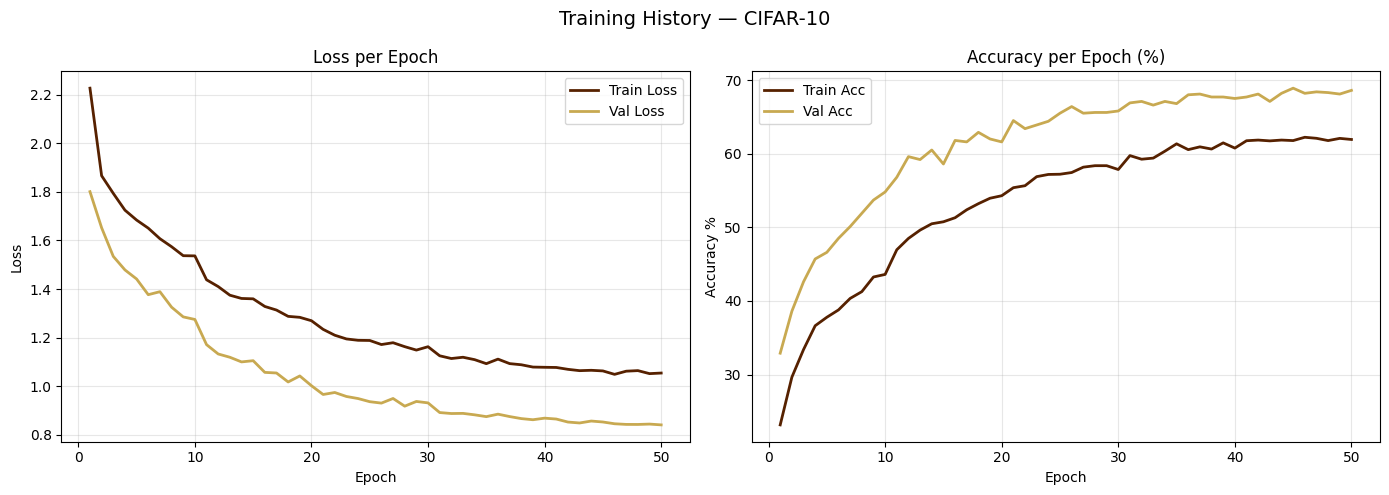

Saved to results/training/CIFAR-10_training_history.png


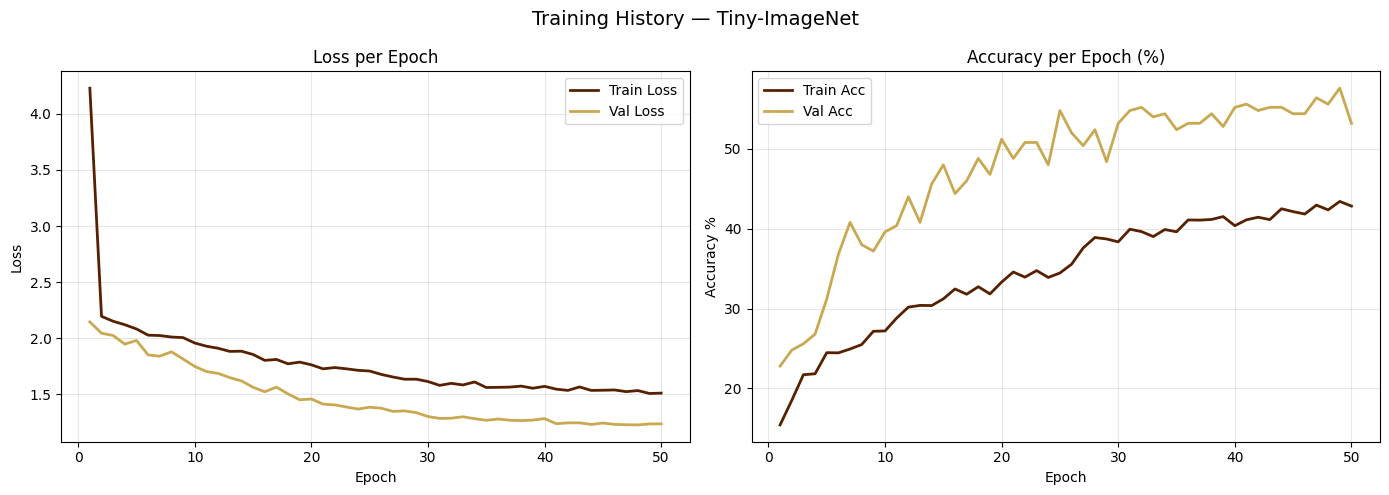

Saved to results/training/Tiny-ImageNet_training_history.png


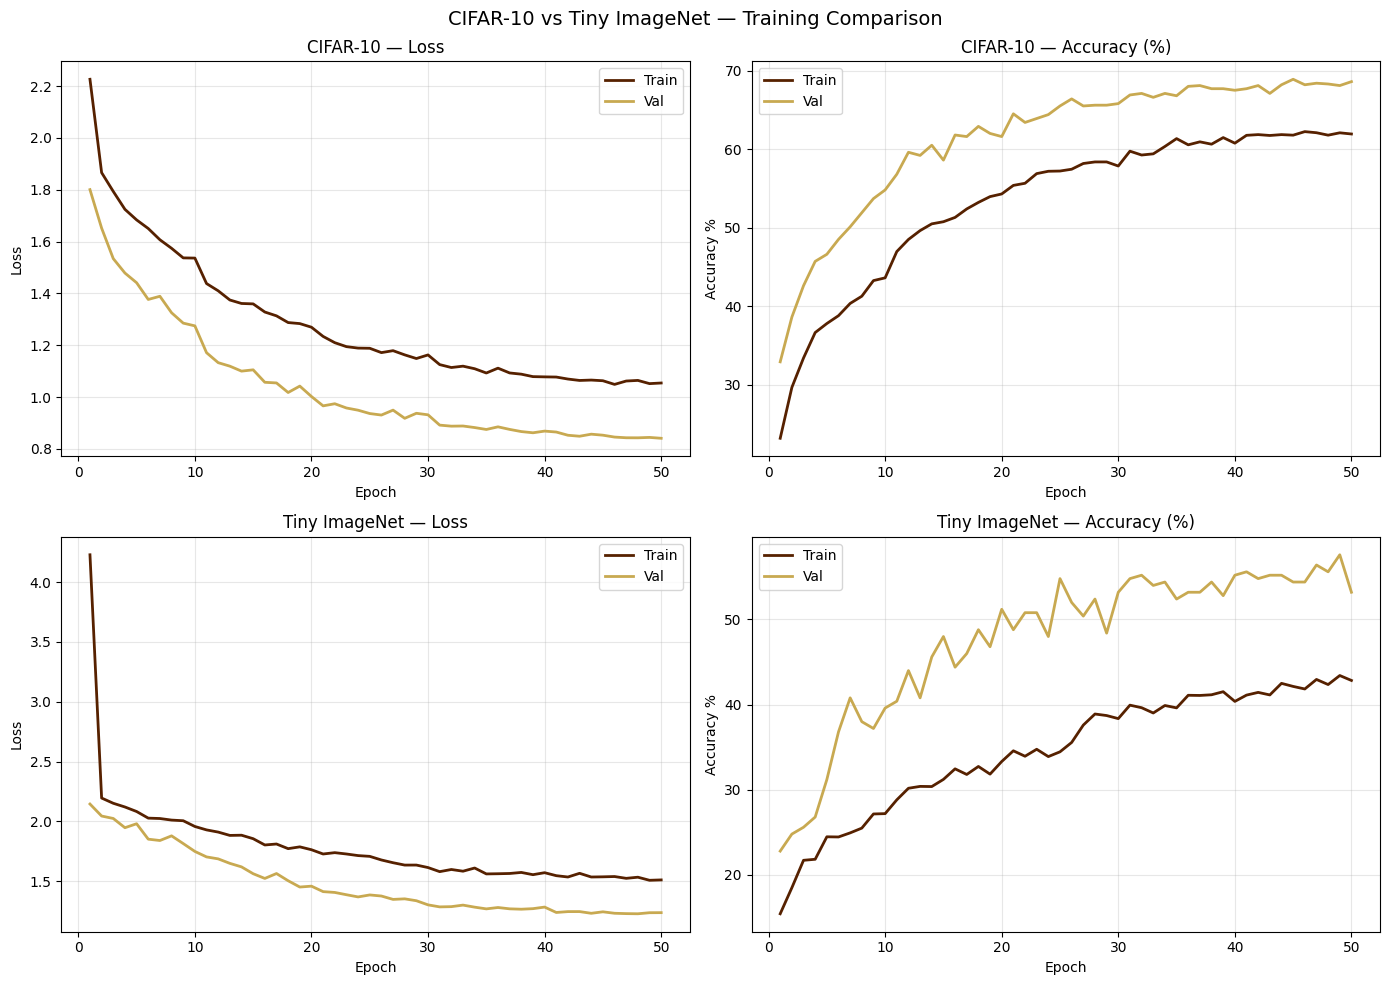

Saved to results/training/comparison_training_curves.png


In [69]:
from utils.train import plot_training_history, plot_comparison

# Plot CIFAR-10 curves
plot_training_history(cifar_history, "CIFAR-10")

# Plot Tiny ImageNet curves
plot_training_history(tiny_history, "Tiny-ImageNet")

# Plot both side by side comparison
plot_comparison(cifar_history, tiny_history)

#Writing and create all functions for evaluation


In [60]:
# Write evaluate.py using Python instead of %%writefile
evaluate_code = '''
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_score,
    recall_score, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize


def get_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (np.array(all_labels),
            np.array(all_preds),
            np.array(all_probs))


def print_classification_report(labels, preds, class_names, dataset_name):
    acc = accuracy_score(labels, preds) * 100
    p   = precision_score(labels, preds, average="weighted") * 100
    r   = recall_score(labels, preds,    average="weighted") * 100
    f1  = f1_score(labels, preds,        average="weighted") * 100
    print(f"\\n{\'=\'*55}")
    print(f"  Classification Report — {dataset_name}")
    print(f"{\'=\'*55}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Precision : {p:.2f}%")
    print(f"  Recall    : {r:.2f}%")
    print(f"  F1 Score  : {f1:.2f}%")
    print(f"{\'=\'*55}")
    print(classification_report(labels, preds, target_names=class_names))
    return acc, p, r, f1


def plot_confusion_matrix(labels, preds, class_names,
                           dataset_name, save_dir="results/evaluation"):
    os.makedirs(save_dir, exist_ok=True)
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Confusion Matrix — {dataset_name}", fontsize=15)
    for ax, data, title in zip(axes,
                                [cm, cm_norm],
                                ["Raw Counts", "Normalized (%)"]):
        im = ax.imshow(data, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        thresh = data.max() / 2
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = data[i, j]
                txt = str(int(val)) if data is cm else f"{val:.1f}%"
                ax.text(j, i, txt, ha="center", va="center",
                        color="white" if val > thresh else "black",
                        fontsize=9)
    plt.tight_layout()
    path = f"{save_dir}/{dataset_name}_confusion_matrix.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved to {path}")


def plot_roc_curves(labels, probs, class_names,
                    dataset_name, save_dir="results/evaluation"):
    os.makedirs(save_dir, exist_ok=True)
    n_classes  = len(class_names)
    labels_bin = label_binarize(labels, classes=range(n_classes))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])
    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr  /= n_classes
    macro_auc  = auc(all_fpr, mean_tpr)
    fig, axes  = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"ROC Curves — {dataset_name}", fontsize=15)
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        axes[0].plot(fpr[i], tpr[i], color=color, lw=1.5,
                     label=f"{cls} (AUC={roc_auc[i]:.2f})")
    axes[0].plot([0,1],[0,1], "k--", lw=1, label="Random (0.50)")
    axes[0].plot(all_fpr, mean_tpr, "b-", lw=2.5,
                 label=f"Macro avg (AUC={macro_auc:.2f})")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve per Class")
    axes[0].legend(loc="lower right", fontsize=9)
    axes[0].grid(True, alpha=0.3)
    sorted_idx = np.argsort([roc_auc[i] for i in range(n_classes)])
    sorted_cls = [class_names[i] for i in sorted_idx]
    sorted_auc = [roc_auc[i]     for i in sorted_idx]
    bars = axes[1].barh(sorted_cls, sorted_auc,
                         color=[colors[i] for i in sorted_idx])
    axes[1].axvline(x=macro_auc, color="blue", linestyle="--",
                    lw=1.5, label=f"Macro={macro_auc:.2f}")
    axes[1].axvline(x=0.5, color="gray", linestyle="--",
                    lw=1, label="Random=0.50")
    axes[1].set_xlim([0.0, 1.05])
    axes[1].set_xlabel("AUC Score")
    axes[1].set_title("AUC Score per Class")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis="x")
    for bar, val in zip(bars, sorted_auc):
        axes[1].text(val+0.01, bar.get_y()+bar.get_height()/2,
                     f"{val:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    path = f"{save_dir}/{dataset_name}_roc_auc.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved to {path}")
    print(f"Macro AUC: {macro_auc:.4f}")
    return roc_auc, macro_auc


def plot_precision_recall(labels, preds, class_names,
                           dataset_name, save_dir="results/evaluation"):
    os.makedirs(save_dir, exist_ok=True)
    precision = precision_score(labels, preds, average=None) * 100
    recall    = recall_score(labels, preds,    average=None) * 100
    f1        = f1_score(labels, preds,        average=None) * 100
    x, w      = np.arange(len(class_names)), 0.25
    fig, ax   = plt.subplots(figsize=(14, 6))
    ax.bar(x-w, precision, w, label="Precision", color="steelblue",  alpha=0.85)
    ax.bar(x,   recall,    w, label="Recall",    color="darkorange", alpha=0.85)
    ax.bar(x+w, f1,        w, label="F1 Score",  color="green",      alpha=0.85)
    ax.set_xlabel("Class")
    ax.set_ylabel("Score (%)")
    ax.set_title(f"Precision Recall F1 — {dataset_name}")
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim([0, 115])
    for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
        ax.text(i-w, p+1, f"{p:.0f}%", ha="center", fontsize=8)
        ax.text(i,   r+1, f"{r:.0f}%", ha="center", fontsize=8)
        ax.text(i+w, f+1, f"{f:.0f}%", ha="center", fontsize=8)
    plt.tight_layout()
    path = f"{save_dir}/{dataset_name}_precision_recall.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved to {path}")


def evaluate_full(model, test_loader, class_names,
                   dataset_name, device,
                   save_dir="results/evaluation"):
    print(f"\\nRunning full evaluation for {dataset_name}...")
    labels, preds, probs = get_predictions(model, test_loader, device)
    acc, p, r, f1 = print_classification_report(
        labels, preds, class_names, dataset_name)
    plot_confusion_matrix(labels, preds, class_names,
                           dataset_name, save_dir)
    roc_auc, macro_auc = plot_roc_curves(
        labels, probs, class_names, dataset_name, save_dir)
    plot_precision_recall(labels, preds, class_names,
                           dataset_name, save_dir)
    return {"accuracy": acc, "precision": p,
            "recall": r, "f1": f1, "macro_auc": macro_auc}
'''

with open("utils/evaluate.py", "w") as f:
    f.write(evaluate_code)

print("evaluate.py written successfully!")

# Verify
with open("utils/evaluate.py", "r") as f:
    content = f.read()
print(f"File size: {len(content)} characters")
print("Functions found:")
for line in content.split("\n"):
    if line.startswith("def "):
        print(f"  {line}")

evaluate.py written successfully!
File size: 7799 characters
Functions found:
  def get_predictions(model, loader, device):
  def print_classification_report(labels, preds, class_names, dataset_name):
  def plot_confusion_matrix(labels, preds, class_names,
  def plot_roc_curves(labels, probs, class_names,
  def plot_precision_recall(labels, preds, class_names,
  def evaluate_full(model, test_loader, class_names,


In [ ]:
# Reload to pick up new version
from importlib import reload
import utils.evaluate
reload(utils.evaluate)

from utils.evaluate import evaluate_full
print("Import successful!")

# Loading created Models

In [61]:
from models.cnn import CNN
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load CIFAR-10 best model
cifar_model = CNN(num_classes=10, input_size=32)
cifar_model.load_state_dict(torch.load(
    "checkpoints/cifar10_cnn_best.pth",
    map_location=device))
cifar_model = cifar_model.to(device)
print("CIFAR-10 model loaded!")

# Load Tiny ImageNet best model
tiny_model = CNN(num_classes=10, input_size=64)
tiny_model.load_state_dict(torch.load(
    "checkpoints/tinyimagenet_cnn_best.pth",
    map_location=device))
tiny_model = tiny_model.to(device)
print("Tiny ImageNet model loaded!")

Device: cpu
CIFAR-10 model loaded!
Tiny ImageNet model loaded!


In [62]:
import os

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

tiny_classes = [class_mapping.get(c, c)
                for c in sorted(os.listdir(TINY_TRAIN))]

print("CIFAR-10 :", cifar_classes)
print("Tiny IN  :", tiny_classes)

CIFAR-10 : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tiny IN  : ['scorpion', 'dugong, Dugong dugon', 'golden retriever', 'Egyptian cat', 'gazelle', 'altar', 'desk', 'rugby ball', 'space heater', 'turnstile']


#Call evaluate functtions



Running full evaluation for CIFAR-10...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



  Classification Report — CIFAR-10
  Accuracy  : 68.69%
  Precision : 68.02%
  Recall    : 68.69%
  F1 Score  : 68.11%

Per class report:
              precision    recall  f1-score   support

    airplane       0.75      0.68      0.72      1000
  automobile       0.82      0.87      0.85      1000
        bird       0.56      0.49      0.52      1000
         cat       0.49      0.39      0.44      1000
        deer       0.63      0.57      0.60      1000
         dog       0.56      0.58      0.57      1000
        frog       0.65      0.81      0.72      1000
       horse       0.74      0.75      0.74      1000
        ship       0.80      0.86      0.83      1000
       truck       0.79      0.85      0.82      1000

    accuracy                           0.69     10000
   macro avg       0.68      0.69      0.68     10000
weighted avg       0.68      0.69      0.68     10000



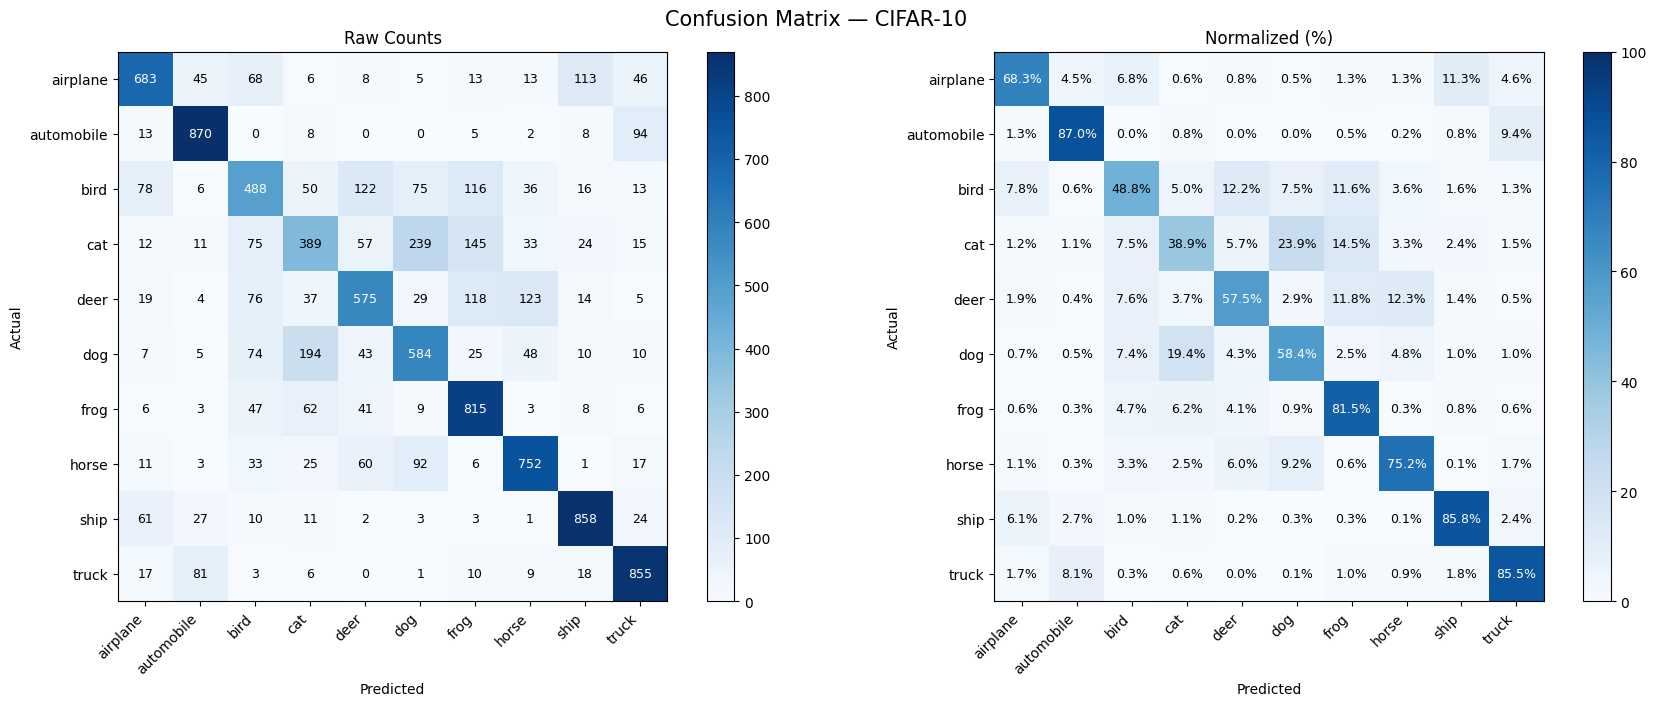

Saved to results/evaluation/CIFAR-10_confusion_matrix.png


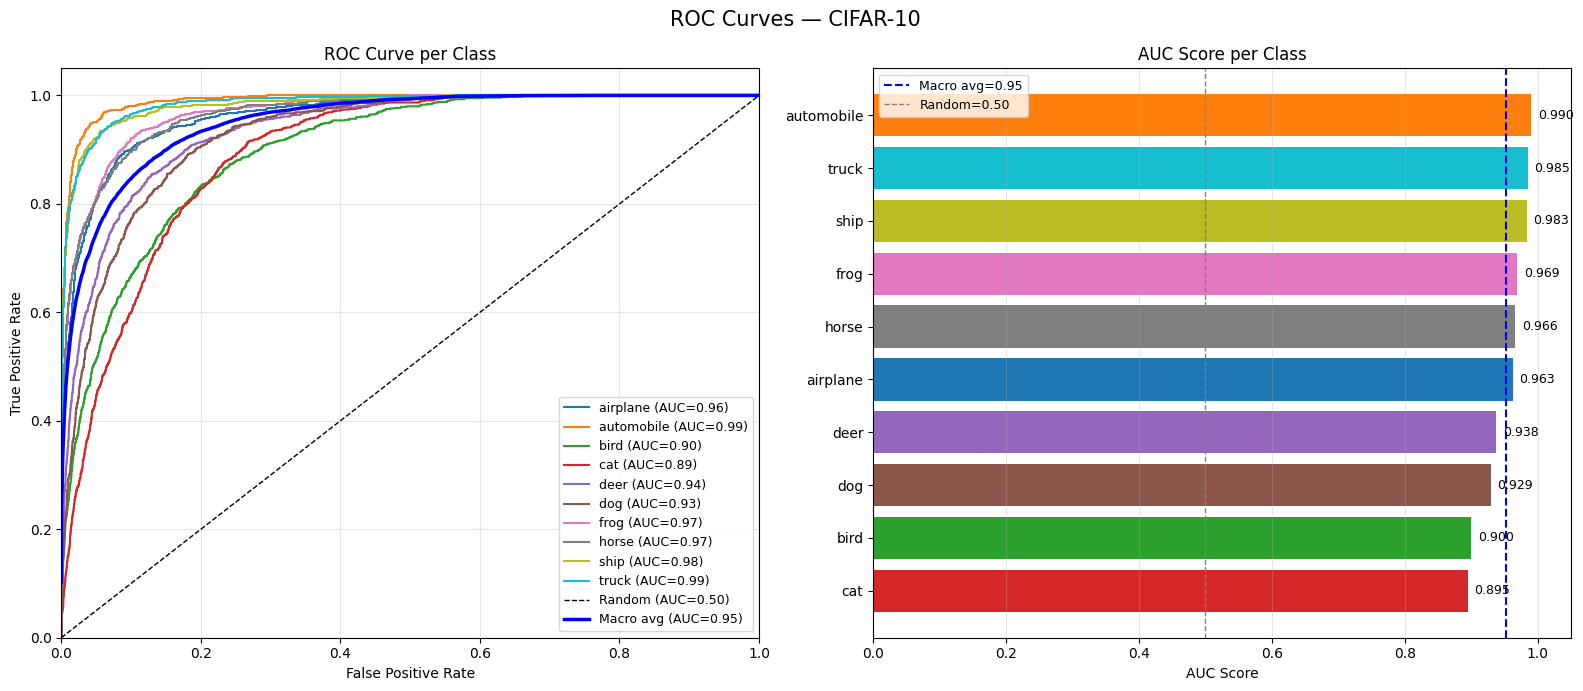

Saved to results/evaluation/CIFAR-10_roc_auc.png
Macro AUC: 0.9519


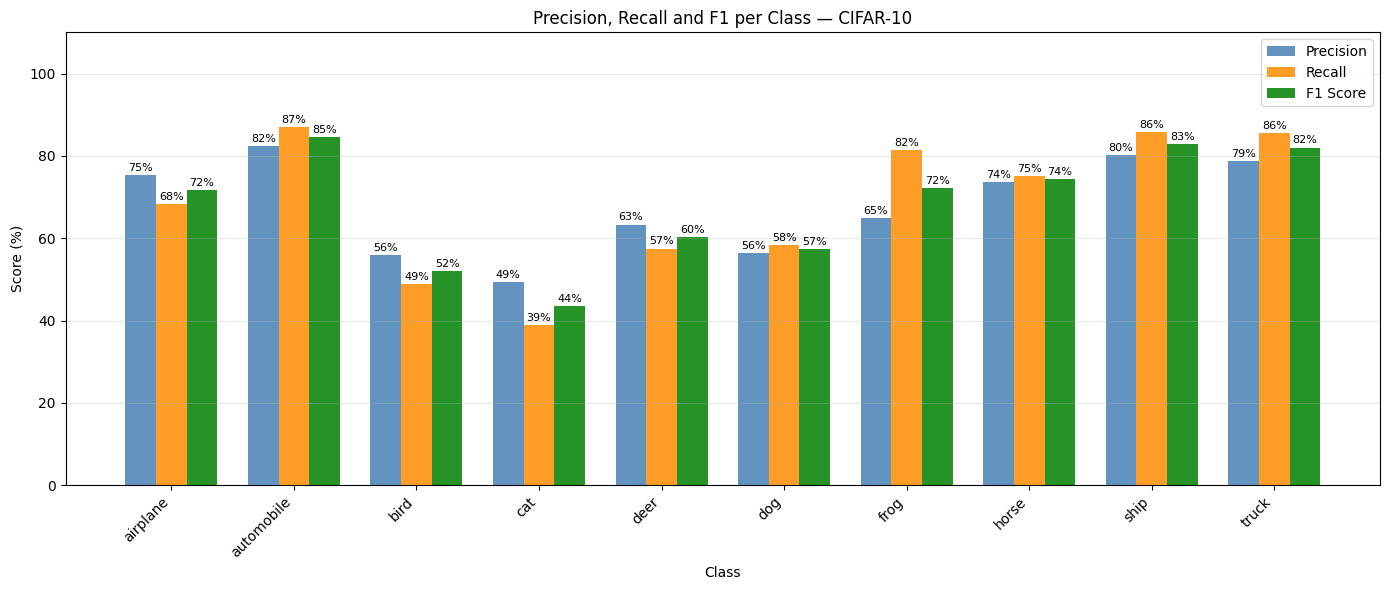

Saved to results/evaluation/CIFAR-10_precision_recall.png

Running full evaluation for Tiny-ImageNet...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



  Classification Report — Tiny-ImageNet
  Accuracy  : 57.20%
  Precision : 57.37%
  Recall    : 57.20%
  F1 Score  : 56.67%

Per class report:
                      precision    recall  f1-score   support

            scorpion       0.67      0.40      0.50        25
dugong, Dugong dugon       0.88      0.92      0.90        25
    golden retriever       0.50      0.56      0.53        25
        Egyptian cat       0.33      0.32      0.33        25
             gazelle       0.50      0.48      0.49        25
               altar       0.73      0.76      0.75        25
                desk       0.41      0.36      0.38        25
          rugby ball       0.66      0.76      0.70        25
        space heater       0.57      0.48      0.52        25
           turnstile       0.49      0.68      0.57        25

            accuracy                           0.57       250
           macro avg       0.57      0.57      0.57       250
        weighted avg       0.57      0.57      0

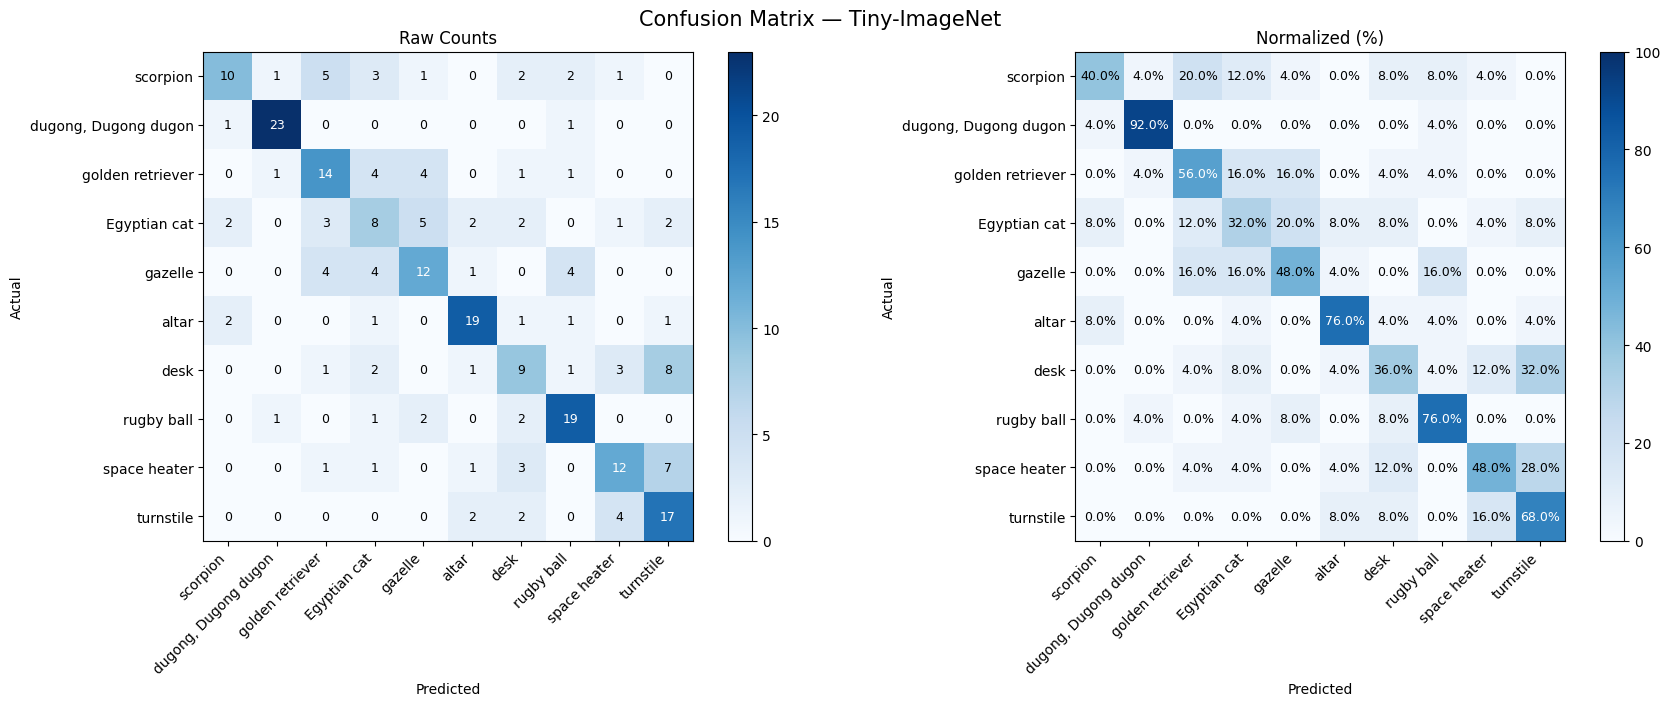

Saved to results/evaluation/Tiny-ImageNet_confusion_matrix.png


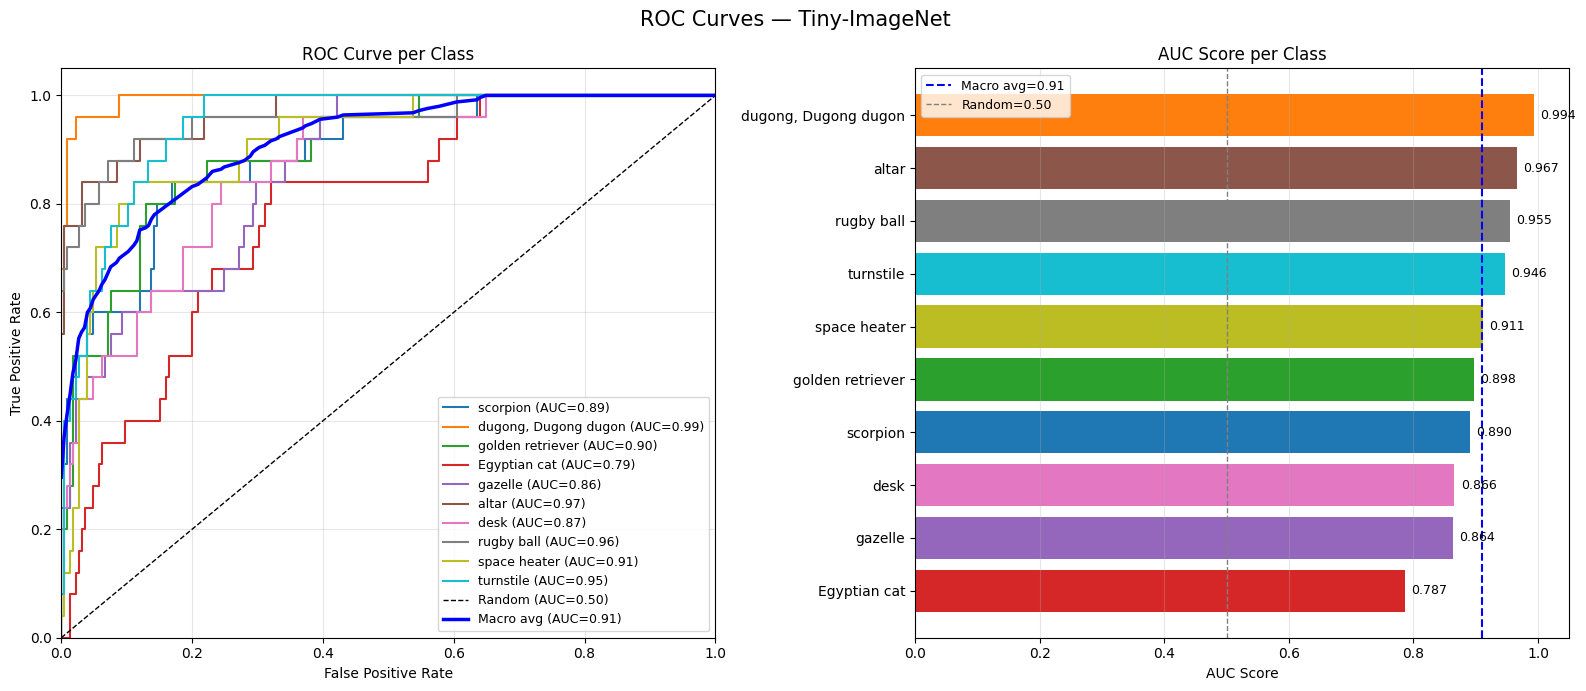

Saved to results/evaluation/Tiny-ImageNet_roc_auc.png
Macro AUC: 0.9102


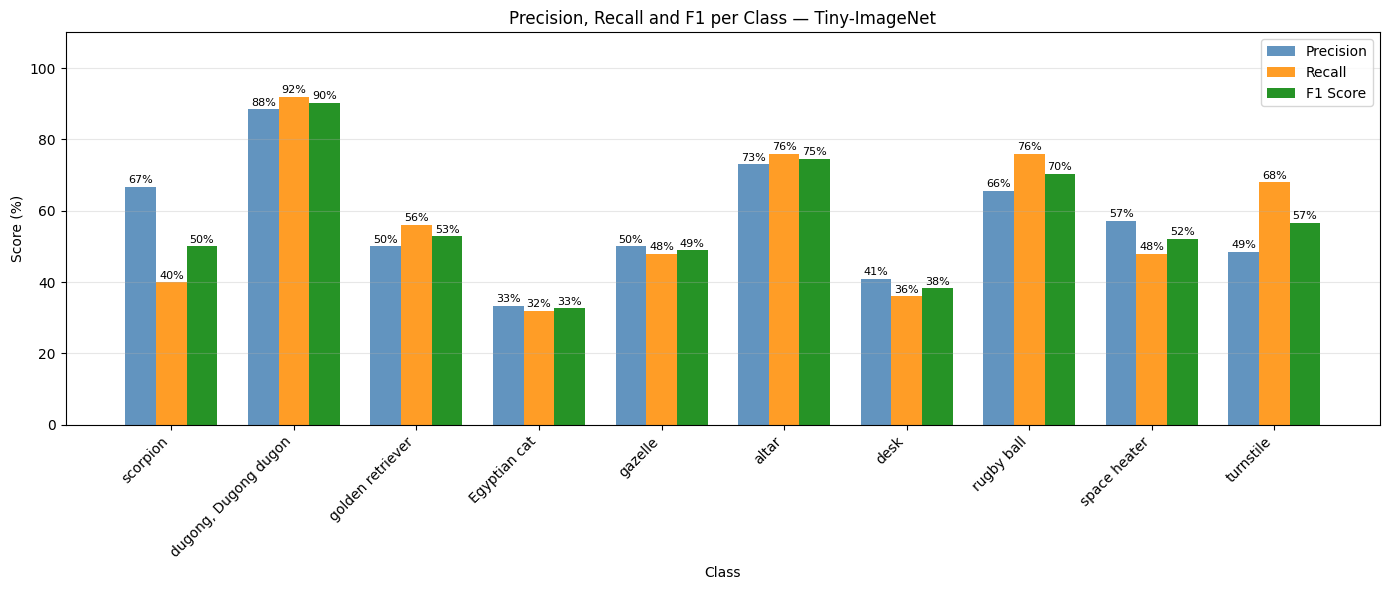

Saved to results/evaluation/Tiny-ImageNet_precision_recall.png

  FINAL RESULTS COMPARISON
Metric                      CIFAR-10   Tiny ImageNet
-------------------------------------------------------
Accuracy                      68.69%          57.20%
Precision                     68.02%          57.37%
Recall                        68.69%          57.20%
F1 Score                      68.11%          56.67%
Macro AUC                    0.9519          0.9102


In [63]:
# CIFAR-10
cifar_results = evaluate_full(
    model        = cifar_model,
    test_loader  = cifar_test_loader,
    class_names  = cifar_classes,
    dataset_name = "CIFAR-10",
    device       = device
)

# Tiny ImageNet
tiny_results = evaluate_full(
    model        = tiny_model,
    test_loader  = tiny_test_loader,
    class_names  = tiny_classes,
    dataset_name = "Tiny-ImageNet",
    device       = device
)

# Final comparison
print("\n" + "="*55)
print("  FINAL RESULTS COMPARISON")
print("="*55)
print(f"{'Metric':<20} {'CIFAR-10':>15} {'Tiny ImageNet':>15}")
print("-"*55)
print(f"{'Accuracy':<20} {cifar_results['accuracy']:>14.2f}% {tiny_results['accuracy']:>14.2f}%")
print(f"{'Precision':<20} {cifar_results['precision']:>14.2f}% {tiny_results['precision']:>14.2f}%")
print(f"{'Recall':<20} {cifar_results['recall']:>14.2f}% {tiny_results['recall']:>14.2f}%")
print(f"{'F1 Score':<20} {cifar_results['f1']:>14.2f}% {tiny_results['f1']:>14.2f}%")
print(f"{'Macro AUC':<20} {cifar_results['macro_auc']:>14.4f}  {tiny_results['macro_auc']:>14.4f}")
print("="*55)